# Modality-Invariant Representation Learning for Fair Skin Disease Classification (Version 1)


## Dataset Split

| Role | Dataset | Modality |
|------|---------|----------|
| **Train (paired)** | HIBA | Clinical + Dermoscopic |
| **Train (unpaired clinical)** | Fitzpatrick17k | Clinical |
| **Train (unpaired derm)** | HAM10000 | Dermoscopic |
| **Eval** | Dermnet | Various |

## Unified 7-Class Taxonomy

| ID | Class |
|----|-------|
| 0 | Melanoma |
| 1 | Nevus |
| 2 | Basal Cell Carcinoma |
| 3 | Actinic Keratosis |
| 4 | Seborrheic Keratosis |
| 5 | Squamous Cell Carcinoma |
| 6 | Other |

## Notebook Roadmap

| Phase | Section |
|-------|---------|
| 0 | Environment setup, Drive mount |
| 1 | Data parsers, label harmonization, CSV building, loaders |
| 2 | Dual-encoder ViT architecture |
| 3 | Multi-objective loss functions |
| 4 | Training loop with Drive checkpointing |
| 5 | Fairness evaluation (EOM, PQD, DPM, FATE) |
| 6 | Ablation studies |
| 7 | Visualization (curves, FST bars, cross-dataset, UMAP) |

**Runtime:** T4 GPU or better. Full training ~8–12 h.

## Phase 0 — Environment Setup

In [1]:
!pip install -q timm einops scikit-learn umap-learn \
               matplotlib seaborn pandas tqdm Pillow \
               shap captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.6 MB/s eta 0:00:00


In [2]:
import os, re, glob, random, math, json, warnings, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

import shap
from captum.attr import (GradientShap, IntegratedGradients,
                         NoiseTunnel, LayerGradCam, LayerAttribution)
from captum.attr import visualization as viz

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
# ── HuggingFace token + backbone weight cache ────────────────────────────
# Set your HF token as a Kaggle secret (Notebook → Add-ons → Secrets → HF_TOKEN)
# or paste it directly here. Without it, downloads are rate-limited to ~100 KB/s.
import os
_hf_token = os.environ.get('HF_TOKEN', '')
if _hf_token:
    os.environ['HUGGING_FACE_HUB_TOKEN'] = _hf_token
    print(f'HF token loaded ({len(_hf_token)} chars).')
else:
    print('[INFO] No HF_TOKEN found — downloads may be slow. '
          'Add it via Kaggle Secrets → HF_TOKEN.')

# Point timm's weight cache to Kaggle working dir so weights survive
# across kernel restarts and are never re-downloaded.
_BACKBONE_CACHE = Path('/kaggle/working/backbone_cache')
_BACKBONE_CACHE.mkdir(exist_ok=True)
os.environ['TORCH_HOME']     = str(_BACKBONE_CACHE)
os.environ['HF_HOME']        = str(_BACKBONE_CACHE)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(_BACKBONE_CACHE)
print(f'Backbone cache dir: {_BACKBONE_CACHE}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
[INFO] No HF_TOKEN found — downloads may be slow. Add it via Kaggle Secrets → HF_TOKEN.
Backbone cache dir: /kaggle/working/backbone_cache


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG
# ════════════════════════════════════════════════════════════════════════════
DRIVE_ROOT = Path('/kaggle/input/datasets')
WORK_ROOT  = Path('/kaggle/working')

CFG = dict(
    # Dataset roots  (read-only)
    hiba_root     = DRIVE_ROOT / 'asosenge/hibaskinlesionsdataset-main',
    fitz_root     = DRIVE_ROOT / 'asosenge/fitzpatrick17k',
    ham_root      = DRIVE_ROOT / 'asosenge/ham10000',
    dermnet_root  = DRIVE_ROOT / 'shubhamgoel27/dermnet',
    # Outputs  (writable)
    csv_dir       = WORK_ROOT / 'csvs',
    ckpt_dir      = WORK_ROOT / 'checkpoints',
    results_dir   = WORK_ROOT / 'results',
    shap_dir      = WORK_ROOT / 'results/shap',
    # Architecture
    backbone      = 'vit_small_patch16_224',
    embed_dim     = 512,
    img_size      = 224,
    # Training
    batch_size    = 32,
    num_epochs    = 30,
    lr            = 1e-4,
    weight_decay  = 1e-4,
    warmup_epochs = 5,
    # Loss weights
    lambda_cls    = 1.0,
    lambda_conf   = 0.5,
    lambda_con    = 1.0,
    lambda_mi     = 1.0,
    temperature   = 0.07,
    # Labels — 7 canonical classes (0-5 + "other")
    num_classes    = 7,
    num_skin_types = 6,
    # Data balancing (applied to train split only via oversampling in the CSV)
    aug_target_per_class = 3000,   # ↑ more minority-class samples per epoch
    aug_target_per_fst   = 500,   # ↑ better dark-FST coverage
    # Ablation flags
    use_conf = True, use_con = True, use_mi = True,
    use_mixup = True,  # manifold MixUp in embedding space (no pixel aug)
)

# ── Canonical label names (all lowercase, no hyphens, consistent spacing) ──
LABEL_NAMES = {
    0: 'melanoma',
    1: 'nevus',
    2: 'basal cell carcinoma',
    3: 'actinic keratosis',
    4: 'seborrheic keratosis',
    5: 'squamous cell carcinoma',
    6: 'other',
}
FST_NAMES = {i: f'FST {i+1}' for i in range(6)}

for k in ['csv_dir','ckpt_dir','results_dir','shap_dir']:
    CFG[k].mkdir(parents=True, exist_ok=True)

print('Config ready. Checking dataset roots:')
for k in ['hiba_root','fitz_root','ham_root','dermnet_root']:
    status = 'OK' if CFG[k].exists() else 'MISSING — update path'
    print(f'  [{status}]  {k}')


Config ready. Checking dataset roots:
  [OK]  hiba_root
  [OK]  fitz_root
  [OK]  ham_root
  [OK]  dermnet_root


## Phase 1 — Data Preparation

### 1-A  Label Taxonomy & Mapping Tables

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL TAXONOMY & MAPPING TABLES
# ════════════════════════════════════════════════════════════════════════════
# Canonical 7 classes (verified against actual CSV values):
#   0  melanoma
#   1  nevus
#   2  basal cell carcinoma
#   3  actinic keratosis
#   4  seborrheic keratosis
#   5  squamous cell carcinoma
#   6  other

import re as _re

def _clean(s: str) -> str:
    """Lowercase, strip, normalise hyphens/underscores to spaces."""
    s = str(s).lower().strip()
    s = _re.sub(r'[-_]+', ' ', s)
    s = _re.sub(r'\s+', ' ', s)
    return s

# ── HAM10000  (dx codes verified from HAM10000_metadata.csv) ─────────────
HAM_MAP = {
    'mel':   0,   # melanoma
    'nv':    1,   # nevus
    'bcc':   2,   # basal cell carcinoma
    'akiec': 3,   # actinic keratosis (HAM groups AK + SCC in-situ together)
    'bkl':   4,   # benign / seborrheic keratosis
    'df':    6,   # dermatofibroma → other
    'vasc':  6,   # vascular lesion → other
}

# ── HIBA  (diagnosis column — verified from hospital-italiano CSV) ────────
HIBA_MAP = {
    'melanoma':                0,
    'solar lentigo':           0,   # melanocytic / lentiginous → melanoma group
    'nevus':                   1,
    'basal cell carcinoma':    2,
    'actinic keratosis':       3,
    'seborrheic keratosis':    4,
    'lichenoid keratosis':     4,   # benign keratosis variant
    'squamous cell carcinoma': 5,
    'dermatofibroma':          6,
    'vascular lesion':         6,
}

# ── Fitzpatrick17k  ('label' column — verified from fitzpatrick17k.csv) ───
FITZ_MAP = {
    # ── Melanoma (0) ────────────────────────────────────────────────────
    'melanoma':                             0,
    'malignant melanoma':                   0,
    'superficial spreading melanoma ssm':   0,
    'lentigo maligna':                      0,
    'lentigo maligna melanoma':             0,
    'acral lentiginous melanoma':           0,
    'nodular melanoma':                     0,
    # ── Nevus (1) ───────────────────────────────────────────────────────
    'nevocytic nevus':                      1,
    'epidermal nevus':                      1,
    'congenital nevus':                     1,
    'halo nevus':                           1,
    'becker nevus':                         1,
    'nevus sebaceous of jadassohn':         1,
    'naevus comedonicus':                   1,
    # ── Basal Cell Carcinoma (2) ─────────────────────────────────────────
    'basal cell carcinoma':                 2,
    'basal cell carcinoma morpheiform':     2,
    'solid cystic basal cell carcinoma':    2,
    # ── Actinic Keratosis (3) ────────────────────────────────────────────
    'actinic keratosis':                   3,
    'porokeratosis actinic':               3,   # actinic variant
    'bowens disease':                      3,
    'keratoacanthoma':                     3,
    # ── Seborrheic Keratosis (4) ─────────────────────────────────────────
    'seborrheic keratosis':                4,
    'seborrhoeic keratosis':               4,
    'lichenoid keratosis':                 4,
    'benign keratosis':                    4,
    # ── Squamous Cell Carcinoma (5) ──────────────────────────────────────
    'squamous cell carcinoma':             5,
    'squamous cell carcinoma in situ':     5,
    # ── Other (6) ────────────────────────────────────────────────────────
    'dermatofibroma':                      6,
    'kaposi sarcoma':                      6,
    'mycosis fungoides':                   6,
    'malignant cutaneous lymphoma':        6,
}

# ── DermNet  (folder-level fallback — per-image from filename in parser) ──
DERMNET_FOLDER_MAP = {
    'melanoma skin cancer nevi and moles':                                0,
    'actinic keratosis basal cell carcinoma and other malignant lesions': 2,
    'seborrheic keratoses and other benign tumors':                       4,
}

def harmonize_label(raw: str, mapping: dict, default: int = 6) -> int:
    """Map a raw diagnosis string → canonical class integer.

    Order of operations:
    1. _clean() — lowercase, strip, normalise hyphens.
    2. Exact match in mapping.
    3. Substring match (key in string OR string in key).
    4. Wildcard: any string containing the word 'nevus' → class 1.
    5. Return default (6 = other).
    """
    s = _clean(raw)
    if s in mapping:
        return mapping[s]
    for k, v in mapping.items():
        if k in s or s in k:
            return v
    if 'nevus' in s or 'nevi' in s:
        return 1
    return default

def parse_fst(raw) -> int:
    """Parse an integer Fitzpatrick skin type (1–6) → index (0–5).
    Returns -1 for missing / out-of-range values.
    """
    try:
        v = int(float(str(raw).strip()))
        return v - 1 if 1 <= v <= 6 else -1
    except (ValueError, TypeError):
        return -1

_ROMAN_TO_INT = {
    'i': 1, 'ii': 2, 'iii': 3, 'iv': 4, 'v': 5, 'vi': 6,
}
def parse_fst_roman(raw) -> int:
    """Parse roman-numeral or integer FST (HIBA uses I–VI strings).
    Returns 0-based index (0=FST I … 5=FST VI), or -1 if unparseable.
    """
    s = str(raw).lower().strip()
    if s in _ROMAN_TO_INT:
        return _ROMAN_TO_INT[s] - 1
    return parse_fst(raw)   # fallback to integer parsing

print('Label taxonomy ready — 7 classes verified against real CSV values.')
print('  FITZ: reads \"label\" column (fine-grained diagnoses)')
print('  HIBA: reads \"diagnosis\" column + \"fitzpatrick_skin_type\" (roman numerals)')
print('  HAM:  reads \"dx\" column + ITA-estimated FST')


Label taxonomy ready — 7 classes verified against real CSV values.
  FITZ: reads "label" column (fine-grained diagnoses)
  HIBA: reads "diagnosis" column + "fitzpatrick_skin_type" (roman numerals)
  HAM:  reads "dx" column + ITA-estimated FST


### 1-B  Dataset Parsers

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# PAIRED PARSERS  (Derm7pt  &  HIBA)
# ════════════════════════════════════════════════════════════════════════════

def _safe_split(df, test_size=0.15, seed=42):
    """Stratified split.  Classes with only 1 sample are kept in train only
    (stratify would fail; a singleton class can't appear in both splits)."""
    if df.empty: return df, df
    # Count samples per class; singletons can't be stratified
    cts      = df['label'].value_counts()
    rare     = cts[cts < 2].index
    df_rare  = df[df['label'].isin(rare)]
    df_rest  = df[~df['label'].isin(rare)]
    if df_rest.empty:
        return df, df.iloc[:0]          # all rare — put everything in train
    try:
        tr, va = train_test_split(df_rest, test_size=test_size,
                                  random_state=seed, stratify=df_rest['label'])
    except ValueError:
        tr, va = train_test_split(df_rest, test_size=test_size, random_state=seed)
    # Rare-class samples go to train only (they can't contribute to val AUROC anyway)
    tr = pd.concat([tr, df_rare], ignore_index=True)
    return tr, va



def _safe_split_3way(df, val_size=0.15, test_size=0.15, seed=42):
    """Three-way stratified split → (train, val, test).

    Proportions (of the full df):
        val  ≈ val_size   (default 15 %)
        test ≈ test_size  (default 15 %)
        train = remainder (~70 %)

    Rare classes (< 2 samples) are kept in train only.
    """
    if df.empty:
        return df, df.iloc[:0], df.iloc[:0]

    cts     = df['label'].value_counts()
    rare    = cts[cts < 2].index
    df_rare = df[df['label'].isin(rare)]
    df_rest = df[~df['label'].isin(rare)]

    if df_rest.empty:
        return df, df.iloc[:0], df.iloc[:0]

    # First carve off the test split from the full remainder
    try:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size,
            random_state=seed, stratify=df_rest['label'])
    except ValueError:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size, random_state=seed)

    # Then carve val from the train+val portion
    # val_size is expressed relative to the *original* df, so rescale
    rel_val = val_size / (1.0 - test_size)
    try:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val,
            random_state=seed, stratify=df_tv['label'])
    except ValueError:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val, random_state=seed)

    df_train = pd.concat([df_train, df_rare], ignore_index=True)
    return df_train, df_val, df_test

print('Split helpers ready.')


Split helpers ready.


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba(root: Path):
    candidates = (
        list(root.rglob('metadata.csv')) +
        list(root.rglob('hiba_metadata.csv')) +
        list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv'))
    )
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}')
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows | columns: {list(meta.columns)}')

    # Validate required columns
    for req in ['isic_id', 'image_type', 'lesion_id', 'diagnosis']:
        if req not in meta.columns:
            print(f'[WARN] HIBA: required column "{req}" missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    fst_col = next((c for c in ['fitzpatrick_skin_type', 'fitzpatrick', 'fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')

    image_path_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_path_map)} entries')

    # ── Per-lesion accumulation ───────────────────────────────────────
    lesion_data = {}   # lesion_id → {label, fst, clinical:[], derm:[]}
    for _, r in meta.iterrows():
        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        diag  = str(r.get('diagnosis', 'other'))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        # Resolve image path
        img_path = image_path_map.get(isic)
        if img_path is None and '.' in isic:
            img_path = image_path_map.get(Path(isic).stem)

        if lid not in lesion_data:
            lesion_data[lid] = {
                'label': harmonize_label(diag, HIBA_MAP),
                'fst':   fst,
                'clinical': [],
                'derm':    [],
            }
        else:
            # Update FST if we now have a valid value
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_path:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(str(img_path))
            else:
                # "clinical: overview" and "clinical: close-up" are both clinical
                lesion_data[lid]['clinical'].append(str(img_path))

    # ── Build rows ────────────────────────────────────────────────────
    paired_rows   = []   # lesions with both modalities
    unpaired_clin = []   # clinical-only images  →  clin_* pool
    unpaired_derm = []   # derm-only images      →  derm_* pool

    for lid, d in lesion_data.items():
        label = d['label']; fst = d['fst']
        base = {'label': label, 'skin_type': fst, 'dataset': 'hiba'}

        if d['clinical'] and d['derm']:
            # Paired: use first of each modality
            paired_rows.append({
                **base,
                'lesion_id':     f'hiba_{lid}',
                'clinical_path': d['clinical'][0],
                'derm_path':     d['derm'][0],
            })
            # Extra clinical images beyond the first also go to unpaired pool
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_path': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_path': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    # ── Split each pool ───────────────────────────────────────────────
    tr_p, va_p, te_p = _safe_split_3way(df_paired) if not df_paired.empty else (pd.DataFrame(),)*3
    tr_uc, va_uc, te_uc = _safe_split_3way(df_uclin) if not df_uclin.empty else (pd.DataFrame(),)*3
    tr_ud, va_ud, te_ud = _safe_split_3way(df_uderm) if not df_uderm.empty else (pd.DataFrame(),)*3

    global _hiba_unpaired_splits
    _hiba_unpaired_splits = (tr_uc, va_uc, te_uc, tr_ud, va_ud, te_ud)

    print(f'[HIBA] paired    : {len(tr_p)} train | {len(va_p)} val | {len(te_p)} test')
    print(f'[HIBA] unpaired clin: {len(tr_uc)} train | {len(va_uc)} val | {len(te_uc)} test')
    print(f'[HIBA] unpaired derm: {len(tr_ud)} train | {len(va_ud)} val | {len(te_ud)} test')

    # Class distribution for paired
    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    # Class distribution for all HIBA images
    all_hiba = pd.concat([df_paired.rename(columns={'clinical_path':'image_path'}).get(['label','skin_type'],pd.DataFrame()),
                           df_uclin[['label','skin_type']] if not df_uclin.empty else pd.DataFrame(),
                           df_uderm[['label','skin_type']] if not df_uderm.empty else pd.DataFrame()])
    if not all_hiba.empty:
        vc2 = all_hiba['label'].value_counts().sort_index()
        print('[HIBA total  ] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc2.items()))
        n_fst = int((all_hiba['skin_type'] >= 0).sum())
        print(f'[HIBA] FST known: {n_fst}/{len(all_hiba)} images')

    return tr_p, va_p, te_p

_hiba_unpaired_splits = (pd.DataFrame(),)*6
print('HIBA parser ready.')


HIBA parser ready.


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED CLINICAL PARSERS  (Fitzpatrick17k | PAD-UFES-20 | DDI)
# ════════════════════════════════════════════════════════════════════════════

def _find_image(img_id, search_dirs, exts=['.jpg','.jpeg','.png'], recursive=False):
    for d in search_dirs:
        for e in exts:
            if recursive:
                # Use rglob for recursive search
                candidates = list(d.rglob(f'{img_id}{e}'))
                if candidates:
                    return candidates[0]
            else:
                # Non-recursive search, directly in the specified directory
                p = d / f'{img_id}{e}'
                if p.exists(): return p
    return None

def _build_image_map(root_dir: Path, exts=['.jpg','.jpeg','.png']):
    image_map = {}
    for ext in exts:
        for p in root_dir.rglob(f'*{ext}'):
            image_map[p.stem] = p
            image_map[p.name] = p 
    return image_map

def parse_fitzpatrick17k(root: Path):
    csvs = list(root.glob('fitzpatrick17k.csv'))
    if not csvs: print(f'[WARN] Fitzpatrick17k CSV missing'); return pd.DataFrame(), pd.DataFrame()
    meta    = pd.read_csv(csvs[0])
    img_dir = root/'data/finalfitz17k' if (root/'data/finalfitz17k').exists() else root

    print(f'[DEBUG FITZ] Building image path map for {img_dir}...')
    image_path_map = _build_image_map(img_dir)
    print(f'[DEBUG FITZ] Image map built with {len(image_path_map)} entries.')

    rows = []
    for _, r in meta.iterrows():
        # fitzpatrick_scale: int column, values 1-6, -1 = unknown
        _fst_raw = r.get('fitzpatrick_scale', r.get('fitzpatrick', -1))
        fst = parse_fst(_fst_raw) if str(_fst_raw).strip() not in ('-1', '-1.0', 'nan', '') else -1
        p   = None
        for col in ['md5hash','image_id','file_name']:
            if col in r.index and pd.notna(r[col]):
                candidate_id = str(r[col])
                p = image_path_map.get(candidate_id)
                if p: break
                # If meta ID is full filename, try lookup by stem
                if '.' in candidate_id:
                    p = image_path_map.get(Path(candidate_id).stem)
                    if p: break
        if p is None and 'url' in r.index:
            base = str(r['url']).split('/')[-1].split('?')[0]
            p = image_path_map.get(base)
            if p is None and '.' in base:
                p = image_path_map.get(Path(base).stem)
        if p is None: continue
        # BUG FIX: read 'label' (fine-grained diagnosis) NOT 'nine_partition_label'
        # (which contains only coarse groups like "inflammatory" → almost all map to class 6)
        raw = str(r.get('label', r.get('nine_partition_label', 'other')))
        rows.append({'image_path': str(p), 'label': harmonize_label(raw, FITZ_MAP),
                     'skin_type': fst, 'dataset': 'fitzpatrick17k'})
    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    fst_known_count = 0
    if not df.empty and 'skin_type' in df.columns:
        fst_known_count = (df.skin_type>=0).sum()
    print(f'Fitzpatrick17k — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test  | FST known: {fst_known_count}')
    vc = df['label'].value_counts().sort_index()
    print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return tr, va, te


print('Clinical parsers ready.')

Clinical parsers ready.


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED DERM PARSERS  (HAM10000 | ISIC 2018)
# ════════════════════════════════════════════════════════════════════════════

def parse_ham10000(root: Path):
    # rglob searches recursively — finds the CSV wherever it lives under root
    csvs = list(root.rglob('HAM10000_metadata.csv'))
    if not csvs:
        print('[WARN] HAM10000 CSV missing'); return pd.DataFrame(), pd.DataFrame()
    
    meta_path = csvs[0]
    meta_root = meta_path.parent          # e.g. .../ham10000/HAM10000/
    print(f'[DEBUG HAM] Found metadata at: {meta_path}')
    meta = pd.read_csv(meta_path)

    # Search for images relative to where the CSV lives, plus common subfolder patterns
    img_dirs = (
        [meta_root/'images'] +
        [meta_root/f'HAM10000_images_part_{i}' for i in [1, 2]] +
        [meta_root/f'images_part_{i}'          for i in [1, 2]] +
        [meta_root]                             # fallback: same folder as CSV
    )

    print(f'[DEBUG HAM] Building image path map...')
    image_path_map = _build_image_map(meta_root)
    print(f'[DEBUG HAM] Image map built with {len(image_path_map)} entries.')

    rows = []
    for _, r in meta.iterrows():
        img_id = str(r.get('image_id', ''))
        dx     = str(r.get('dx', 'other')).lower().strip()
        # Try the map first (fast), fall back to directory search
        p = image_path_map.get(img_id) or _find_image(img_id, img_dirs)
        if p:
            rows.append({'image_path': str(p), 'label': HAM_MAP.get(dx, 6),
                         'skin_type': -1, 'dataset': 'ham10000'})

    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    print(f'HAM10000       — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test')
    return tr, va, te

print('Dermoscopic parsers ready.')

Dermoscopic parsers ready.


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# EVALUATION DATASET PARSERS  (DermNet | generic folder)
# ════════════════════════════════════════════════════════════════════════════

def _dermnet_label_from_filename(stem: str, folder_label: int) -> int:
    s = _clean(stem)   # lowercase, hyphens → spaces
    # Fine-grained token rules (most-specific first)
    if 'squamous cell carcinoma' in s or 'squamous' in s:
        return 5
    if 'basal cell carcinoma' in s or ('basal' in s and 'cell' in s):
        return 2
    if 'actinic keratosis' in s or 'actinic' in s:
        return 3
    if 'nevus' in s or 'nevi' in s or 'mole' in s:
        return 1
    if 'melanoma mimic' in s or 'mimic' in s:
        return 0
    if 'seborrheic' in s or 'seborrhoeic' in s or 'seborrhe' in s:
        return 4
    # Fall back to the folder-level label
    return folder_label


def parse_dermnet(root: Path) -> pd.DataFrame:
    rows = []
    for folder in sorted(root.rglob('*')):
        if not folder.is_dir():
            continue
        folder_clean = _clean(folder.name)
        folder_label = harmonize_label(folder_clean, DERMNET_FOLDER_MAP, default=6)
        for f in folder.iterdir():
            if f.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue
            img_label = _dermnet_label_from_filename(f.stem, folder_label)
            rows.append({
                'image_path': str(f),
                'label':      img_label,
                'skin_type':  -1,
                'dataset':    'dermnet',
            })
    df = pd.DataFrame(rows)
    print(f'DermNet          (eval) — {len(df):>6} images')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        for lbl, cnt in vc.items():
            print(f'  class {lbl} ({LABEL_NAMES.get(lbl,"?")}): {cnt}')
    return df


# ── ITA-based Fitzpatrick Skin Type estimator ─────────────────────────────
_ITA_BRACKETS = [
    ( 55.0,  float('inf'), 0),
    ( 28.0,  55.0,         1),
    ( 10.0,  28.0,         2),
    (-30.0,  10.0,         3),
    (-55.0, -30.0,         4),
    (float('-inf'), -55.0, 5),
]

def _ita_to_fst(ita: float) -> int:
    for lo, hi, fst in _ITA_BRACKETS:
        if lo < ita <= hi:
            return fst
    return _ITA_BRACKETS[-1][2]

def _estimate_fst_single(path: str, min_skin_frac: float = 0.05, thumb_size: int = 96) -> int:
    try:
        from skimage import color as _skcolor
        img = Image.open(path).convert('RGB')
        img = img.resize((thumb_size, thumb_size), Image.BILINEAR)
        rgb = np.asarray(img, dtype=np.float32) / 255.0
        lab = _skcolor.rgb2lab(rgb)
        L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
        skin_mask = (L > 20) & (L < 90) & (a > 2) & (b > 5)
        if skin_mask.mean() < min_skin_frac:
            return -1
        mean_L = float(L[skin_mask].mean())
        mean_b = float(b[skin_mask].mean())
        if abs(mean_b) < 1e-6:
            return -1
        return _ita_to_fst(float(np.degrees(np.arctan((mean_L - 50.0) / mean_b))))
    except Exception:
        return -1

def estimate_fst_for_csv(df: pd.DataFrame, n_jobs: int = 4, cache_csv: Path = None) -> pd.DataFrame:
    if cache_csv is not None and Path(cache_csv).exists():
        cached = pd.read_csv(cache_csv)
        if 'skin_type' in cached.columns and len(cached) == len(df):
            df = df.copy()
            df['skin_type'] = cached['skin_type'].values
            print(f'  [FST cache] loaded {(df["skin_type"]>=0).sum()}/{len(df)} from {Path(cache_csv).name}')
            return df
    print(f'  Estimating FST via ITA for {len(df)} images (n_jobs={n_jobs}) …')
    from concurrent.futures import ThreadPoolExecutor
    paths = df['image_path'].tolist()
    with ThreadPoolExecutor(max_workers=n_jobs) as ex:
        fst_values = list(tqdm(ex.map(_estimate_fst_single, paths),
                               total=len(paths), desc='  ITA-FST', leave=True))
    df = df.copy()
    df['skin_type'] = fst_values
    n_known = sum(v >= 0 for v in fst_values)
    print(f'  FST estimated: {n_known}/{len(df)} ({100*n_known/max(len(df),1):.1f}%)')
    for fi in range(6):
        cnt = sum(v == fi for v in fst_values)
        if cnt: print(f'    FST {fi+1}: {cnt:>5}')
    if cache_csv is not None:
        df.to_csv(cache_csv, index=False)
        print(f'  Saved FST cache → {Path(cache_csv).name}')
    return df

print('Evaluation parsers + ITA-FST estimator ready.')


Evaluation parsers + ITA-FST estimator ready.


### 1-C  Build CSVs & Data Loaders

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD ALL CSVs
# ════════════════════════════════════════════════════════════════════════════

def augment_balanced(df, target_per_class=3000, target_per_fst=500, seed=42):
    if df.empty:
        return df
    rng = np.random.default_rng(seed)

    # Pass 1: class balance
    parts = []
    for cls in sorted(df['label'].unique()):
        sub = df[df['label'] == cls]
        if len(sub) < target_per_class:
            extra = sub.sample(n=target_per_class - len(sub), replace=True,
                               random_state=int(rng.integers(1_000_000)))
            parts.append(pd.concat([sub, extra], ignore_index=True))
        else:
            parts.append(sub)
    df_bal = pd.concat(parts, ignore_index=True)

    # Pass 2: FST balance (known FST groups only)
    if 'skin_type' in df_bal.columns:
        fst_parts, df_unk = [], df_bal[df_bal['skin_type'] < 0]
        for fst in range(6):
            sub = df_bal[df_bal['skin_type'] == fst]
            if sub.empty: continue
            if len(sub) < target_per_fst:
                extra = sub.sample(n=target_per_fst - len(sub), replace=True,
                                   random_state=int(rng.integers(1_000_000)))
                fst_parts.append(pd.concat([sub, extra], ignore_index=True))
            else:
                fst_parts.append(sub)
        if fst_parts:
            df_bal = pd.concat(fst_parts + [df_unk], ignore_index=True)

    return df_bal.sample(frac=1, random_state=seed).reset_index(drop=True)


def _verify_labels(df, name, n_classes=7):
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, n_classes - 1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df


# ── Step 1: Parse ──────────────────────────────────────────────────────────
print('='*60, '\nParsing datasets ...')
hiba_tr_p, hiba_va_p, hiba_te_p = parse_hiba(CFG['hiba_root'])
hiba_tr_uc, hiba_va_uc, hiba_te_uc, hiba_tr_ud, hiba_va_ud, hiba_te_ud = _hiba_unpaired_splits

fitz_tr, fitz_va, fitz_te = parse_fitzpatrick17k(CFG['fitz_root'])
ham_tr,  ham_va,  ham_te  = parse_ham10000(CFG['ham_root'])

# ── Step 2: Combine into three pools ──────────────────────────────────────
# Pool A — HIBA paired (clinical+dermoscopic → used for L_MI loss)
df_paired_all = pd.concat([hiba_tr_p, hiba_va_p, hiba_te_p], ignore_index=True)

# Pool B — Unpaired clinical (Fitzpatrick17k + HIBA clinical-only)
df_clin_all = pd.concat([fitz_tr, fitz_va, fitz_te,
                          hiba_tr_uc, hiba_va_uc, hiba_te_uc], ignore_index=True)

# Pool C — Unpaired derm (HAM10000 + HIBA derm-only)
df_derm_all = pd.concat([ham_tr, ham_va, ham_te,
                          hiba_tr_ud, hiba_va_ud, hiba_te_ud], ignore_index=True)

# Verify labels
print('\nLabel verification ...')
df_paired_all = _verify_labels(df_paired_all, 'HIBA paired (all)')
df_clin_all   = _verify_labels(df_clin_all,   'Clinical unpaired (all)')
df_derm_all   = _verify_labels(df_derm_all,   'Derm unpaired (all)')

# ── Step 3: Split combined pools ONCE ─────────────────────────────────────
# Single stratified split guarantees every class and FST in every split.
print('\nSplitting combined pools (70/15/15 stratified) ...')
paired_train, paired_val, paired_test = _safe_split_3way(df_paired_all, seed=SEED)
clin_train,   clin_val,   clin_test   = _safe_split_3way(df_clin_all,   seed=SEED)
derm_train,   derm_val,   derm_test   = _safe_split_3way(df_derm_all,   seed=SEED)

print(f'  Paired  : {len(paired_train)} tr | {len(paired_val)} va | {len(paired_test)} te')
print(f'  Clinical: {len(clin_train)} tr | {len(clin_val)} va | {len(clin_test)} te')
print(f'  Derm    : {len(derm_train)} tr | {len(derm_val)} va | {len(derm_test)} te')

# ── Step 4: Augment ONLY train splits ─────────────────────────────────────
print('\nAugmenting train splits ...')
_t_pc = CFG['aug_target_per_class']
_t_pf = CFG['aug_target_per_fst']
paired_train = augment_balanced(paired_train, _t_pc, _t_pf, seed=SEED)
clin_train   = augment_balanced(clin_train,   _t_pc, _t_pf, seed=SEED)
derm_train   = augment_balanced(derm_train,   _t_pc, _t_pf, seed=SEED)
print(f'  paired_train after aug: {len(paired_train):,}')
print(f'  clin_train   after aug: {len(clin_train):,}')
print(f'  derm_train   after aug: {len(derm_train):,}')

# ── DermNet eval ───────────────────────────────────────────────────────────
print('\nBuilding DermNet evaluation set ...')
dermnet_eval = parse_dermnet(CFG['dermnet_root'])
dermnet_eval = _verify_labels(dermnet_eval, 'DermNet eval')
if not dermnet_eval.empty:
    _dermnet_cache = CFG['csv_dir'] / 'eval_dermnet_fst_cache.csv'
    dermnet_eval = estimate_fst_for_csv(dermnet_eval, n_jobs=4, cache_csv=_dermnet_cache)

# ── Save ───────────────────────────────────────────────────────────────────
save_map = {
    'paired_train.csv': paired_train, 'paired_val.csv': paired_val,   'paired_test.csv': paired_test,
    'clin_train.csv'  : clin_train,   'clin_val.csv'  : clin_val,     'clin_test.csv'  : clin_test,
    'derm_train.csv'  : derm_train,   'derm_val.csv'  : derm_val,     'derm_test.csv'  : derm_test,
    'eval_dermnet.csv': dermnet_eval,
}
csv_dir = CFG['csv_dir']
for fname, df in save_map.items():
    if not df.empty:
        df.to_csv(csv_dir / fname, index=False)
        print(f'  Saved {fname:<25} ({len(df):>6} rows)')

print(f'\nTotal train : {len(paired_train)+len(clin_train)+len(derm_train):,}')
print(f'Total val   : {len(paired_val)+len(clin_val)+len(derm_val):,}')
print(f'Total test  : {len(paired_test)+len(clin_test)+len(derm_test):,}')


Parsing datasets ...
[HIBA] 1616 rows | columns: ['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'benign_malignant', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'patient_id', 'personal_hx_mm', 'sex']
[HIBA] FST column: fitzpatrick_skin_type
[HIBA] image map: 3232 entries
[HIBA] paired    : 202 train | 44 val | 44 test
[HIBA] unpaired clin: 38 train | 9 val | 9 test
[HIBA] unpaired derm: 686 train | 147 val | 147 test
[HIBA paired] classes: melanoma=46  nevus=44  basal cell carcinoma=99  actinic keratosis=15  seborrheic keratosis=20  squamous cell carcinoma=39  other=27
[HIBA total  ] classes: melanoma=225  nevus=558  basal cell carcinoma=241  actinic keratosis=48  seborrheic keratosis=50  squamous cell carcinoma=119  other=85
[HIBA] FST known: 1218/1326 images
[DEBUG FITZ] Buildi

  ITA-FST:   0%|          | 0/19559 [00:00<?, ?it/s]

  FST estimated: 17156/19559 (87.7%)
    FST 1:  1061
    FST 2:  4564
    FST 3:  3686
    FST 4:  5283
    FST 5:  1992
    FST 6:   570
  Saved FST cache → eval_dermnet_fst_cache.csv
  Saved paired_train.csv          (  4446 rows)
  Saved paired_val.csv            (    44 rows)
  Saved paired_test.csv           (    44 rows)
  Saved clin_train.csv            ( 13293 rows)
  Saved clin_val.csv              (  2495 rows)
  Saved clin_test.csv             (  2495 rows)
  Saved derm_train.csv            ( 10288 rows)
  Saved derm_val.csv              (  1650 rows)
  Saved derm_test.csv             (  1650 rows)
  Saved eval_dermnet.csv          ( 19559 rows)

Total train : 28,027
Total val   : 4,189
Total test  : 4,189


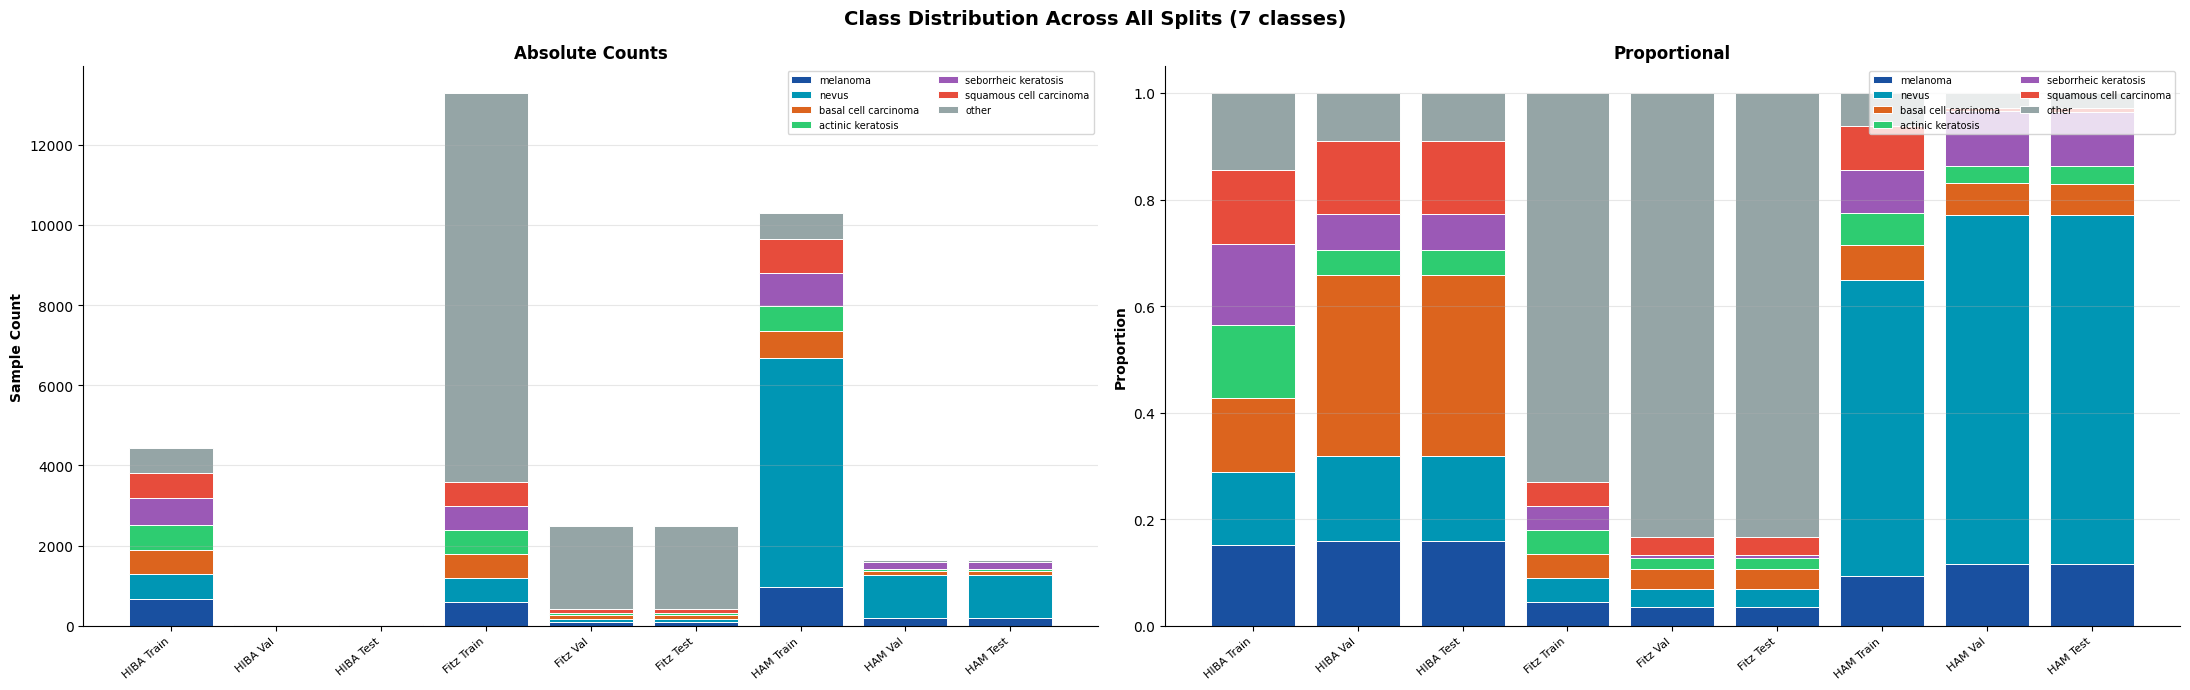

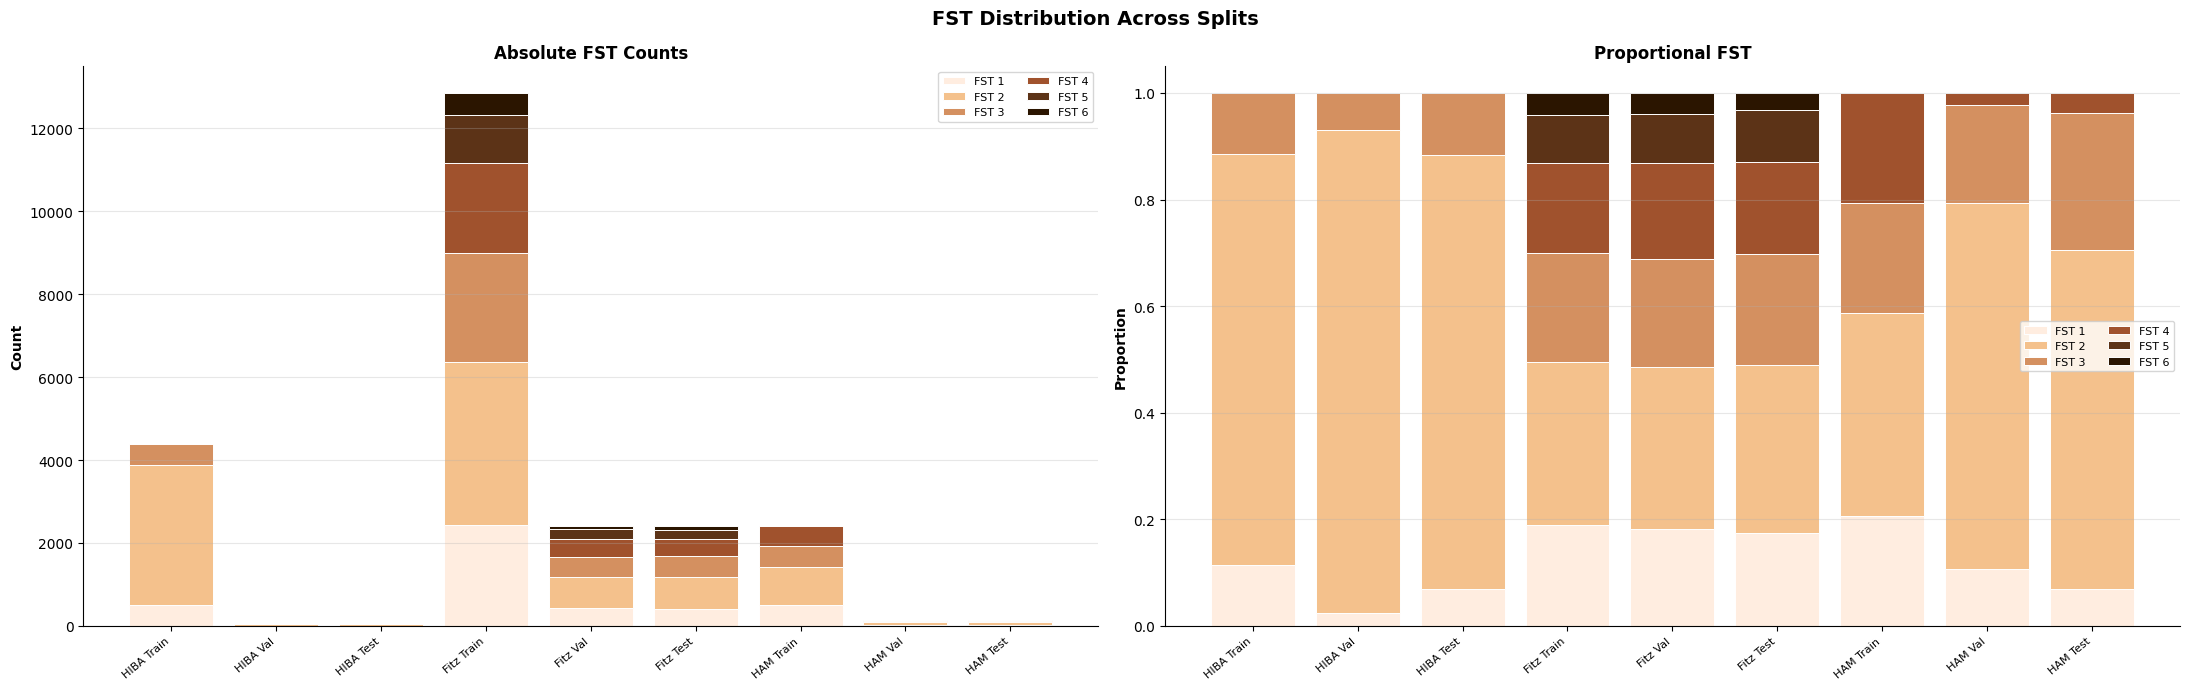

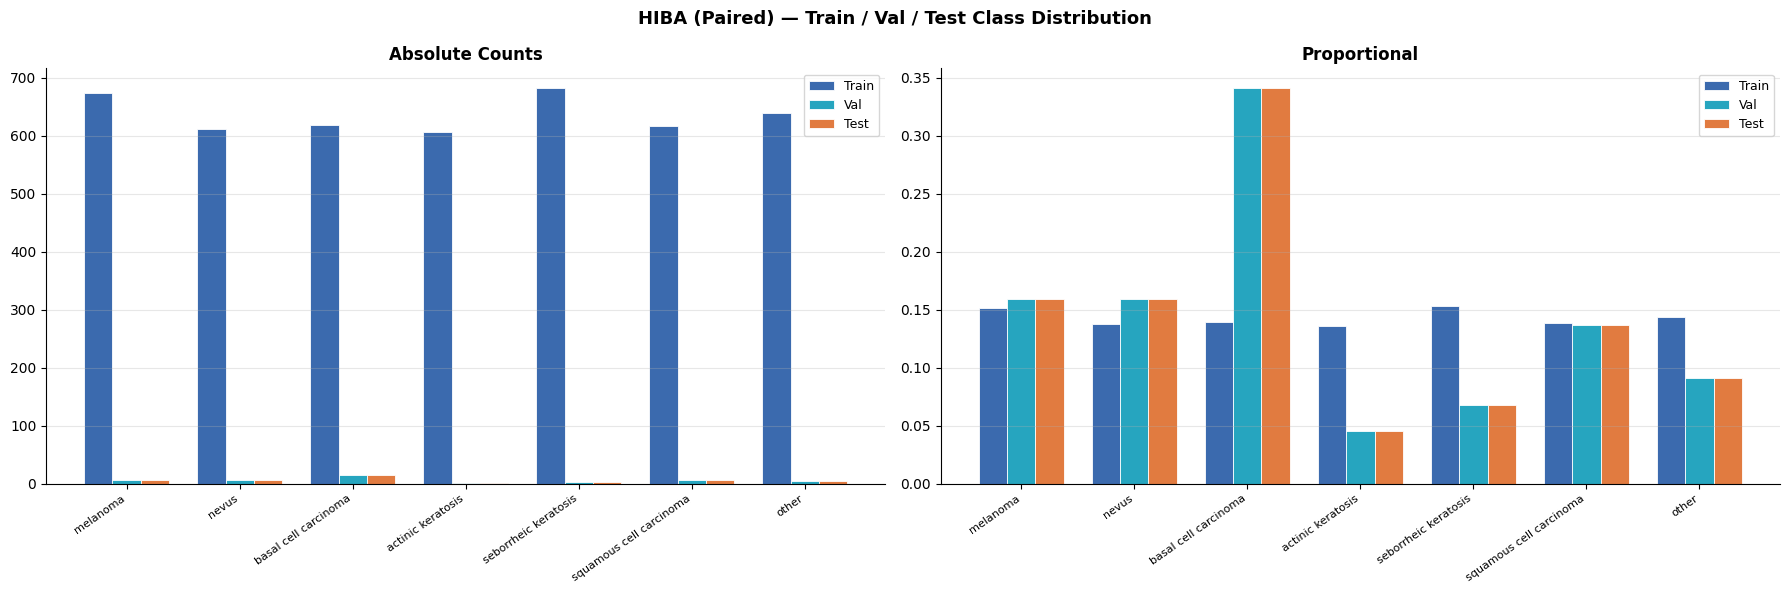

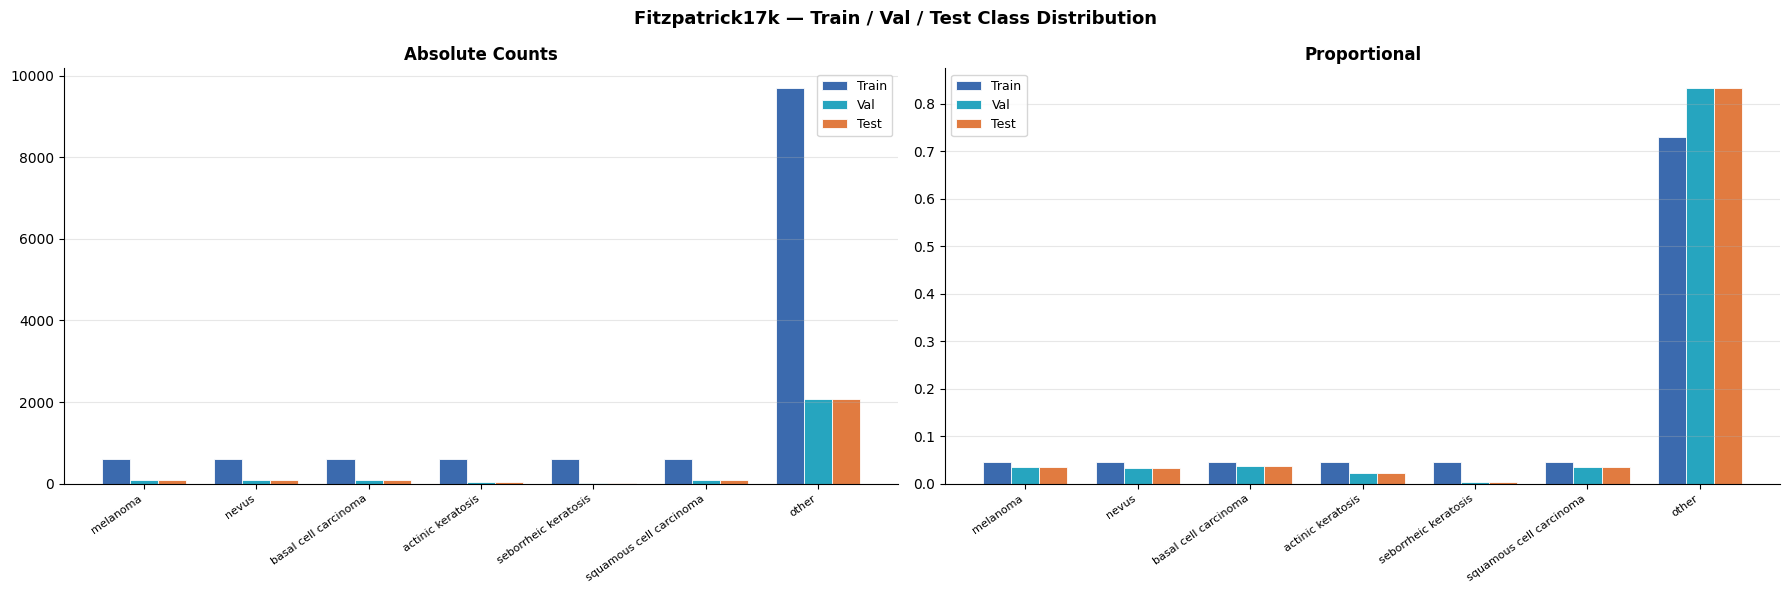

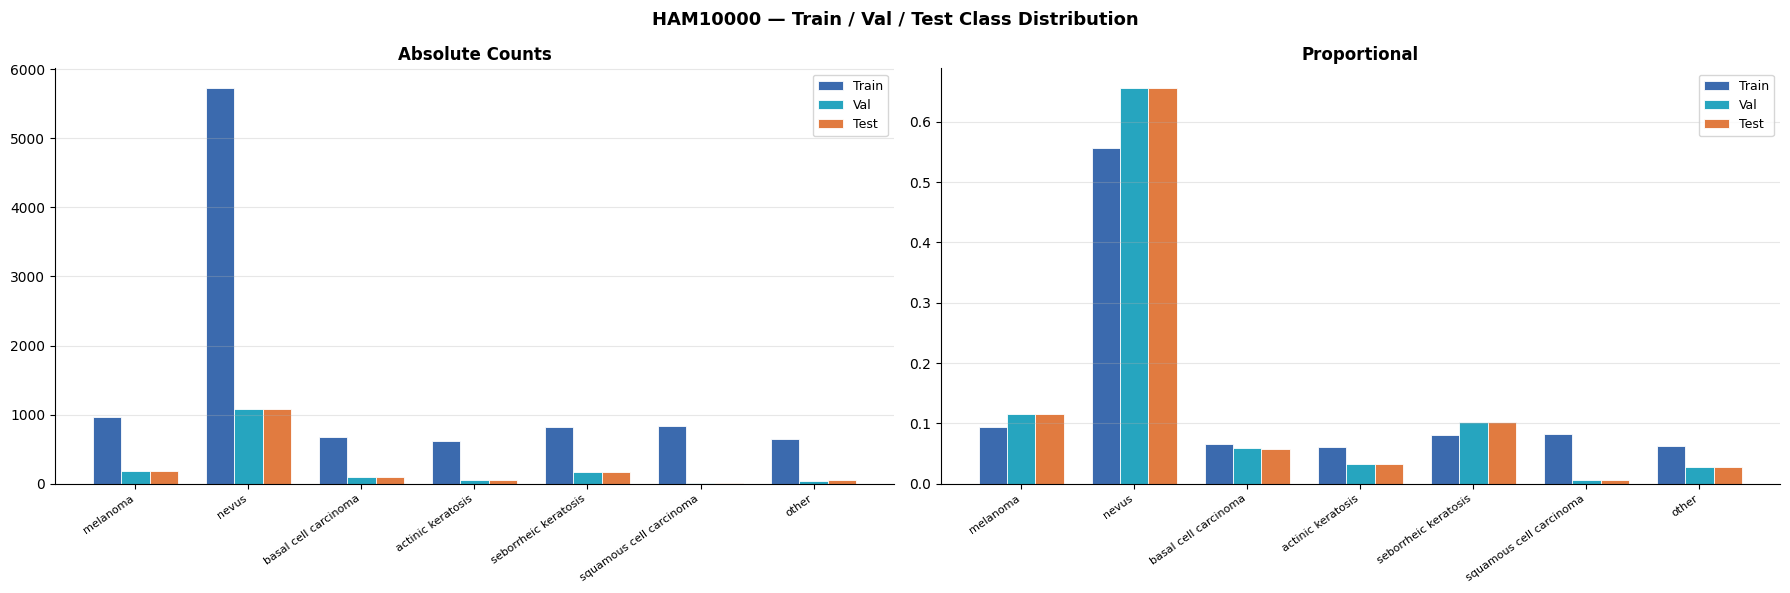

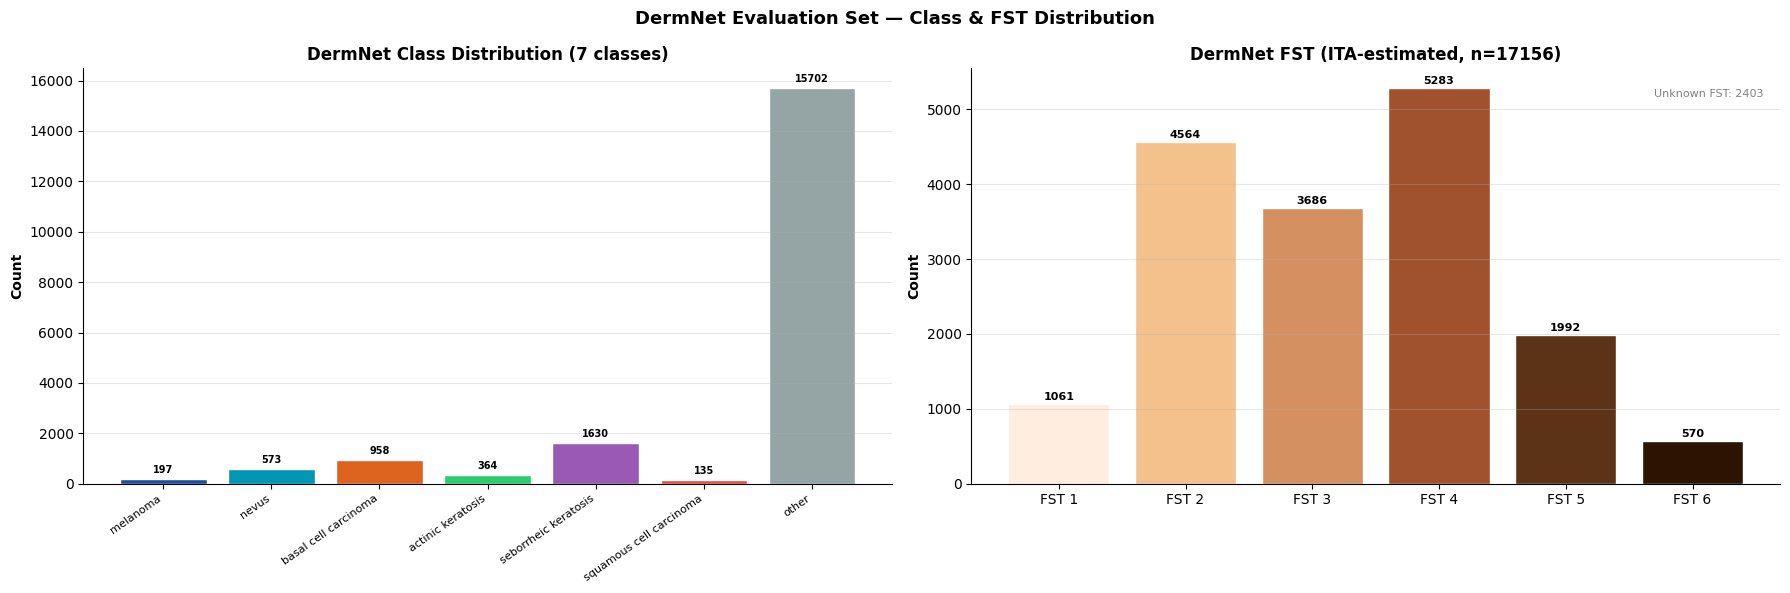

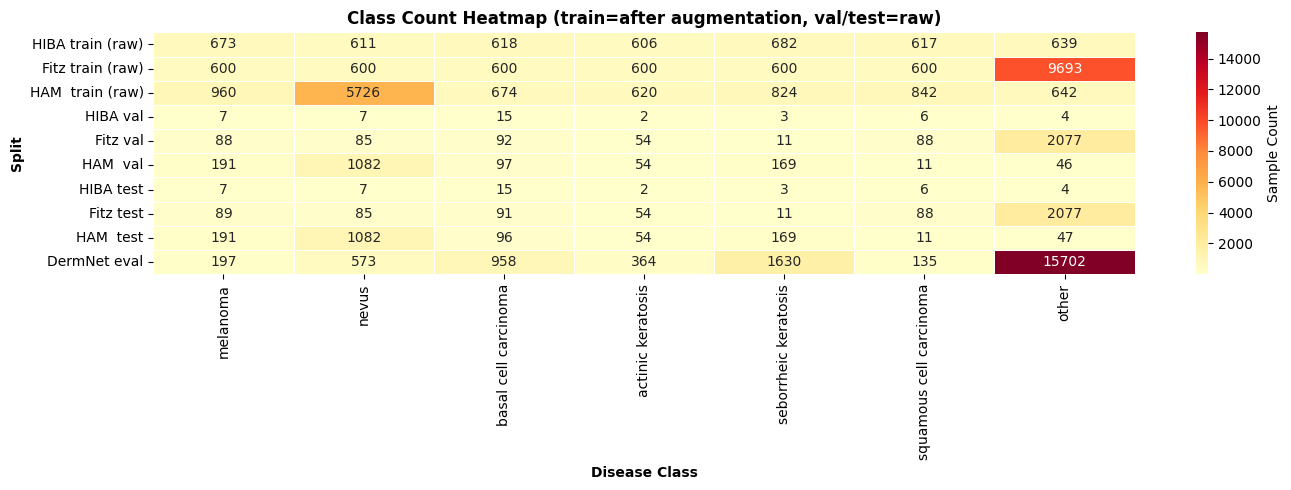


── Coverage Summary ─────────────────────────────────────
                Total rows  FST known  FST %  Class=Other Other %
Dataset                                                          
HIBA                  4446       4386  98.7%          639   14.4%
Fitzpatrick17k       13293      12854  96.7%         9693   72.9%
HAM10000             10288       2420  23.5%          642    6.2%
DermNet              19559      17156  87.7%        15702   80.3%

EDA visualizations saved.


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — DATASET DISTRIBUTION VISUALIZATIONS  (7 classes)
# ════════════════════════════════════════════════════════════════════════════
import warnings as _w; _w.filterwarnings('ignore')

_LN  = LABEL_NAMES                          # {0:'melanoma', …, 6:'other'}
_LBL = [_LN[i] for i in range(7)]           # ordered list
_FST = {i: f'FST {i+1}' for i in range(6)}

_PAL_CLS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6','#E74C3C','#95A5A6']
_PAL_FST = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']

csv_dir = CFG['csv_dir']
def _load(fname):
    p = csv_dir / fname
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

# ── Load all splits ───────────────────────────────────────────────────────
_splits = {}
for tag, fname in [
    ('HIBA Train', 'paired_train.csv'), ('HIBA Val', 'paired_val.csv'),   ('HIBA Test', 'paired_test.csv'),
    ('Fitz Train', 'clin_train.csv'),   ('Fitz Val', 'clin_val.csv'),     ('Fitz Test', 'clin_test.csv'),
    ('HAM Train',  'derm_train.csv'),   ('HAM Val',  'derm_val.csv'),     ('HAM Test',  'derm_test.csv'),
]:
    d = _load(fname)
    if d.empty: continue
    # normalise clinical_path → image_path for paired sets
    if 'image_path' not in d.columns and 'clinical_path' in d.columns:
        d = d.rename(columns={'clinical_path': 'image_path'})
    _splits[tag] = d

_dermnet = _load('eval_dermnet.csv')

# ──────────────────────────────────────────────────────────────────────────
# FIG 1  Class distribution across ALL splits (stacked absolute + proportional)
# ──────────────────────────────────────────────────────────────────────────
if _splits:
    _snames = list(_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('Class Distribution Across All Splits (7 classes)', fontsize=14, fontweight='bold')
    x = np.arange(len(_snames))
    bot_abs = np.zeros(len(_snames))
    bot_prop = np.zeros(len(_snames))
    totals = np.array([len(_splits[s]) for s in _snames], dtype=float)
    for ci in range(7):
        vals = np.array([_splits[s]['label'].value_counts().get(ci, 0) for s in _snames])
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(totals,1), bottom=bot_prop, color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(totals,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute Counts', 'Sample Count'),
        (axes[1], 'Proportional',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_snames, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='upper right')
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_class_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 2  FST distribution (only splits with FST annotations)
# ──────────────────────────────────────────────────────────────────────────
_fst_splits = {s: d for s, d in _splits.items()
               if 'skin_type' in d.columns and (d['skin_type'] >= 0).any()}
if _fst_splits:
    _fs = list(_fst_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('FST Distribution Across Splits', fontsize=14, fontweight='bold')
    x = np.arange(len(_fs))
    bot_abs = np.zeros(len(_fs)); bot_prop = np.zeros(len(_fs))
    for fi in range(6):
        vals  = np.array([(d['skin_type'] == fi).sum() for d in _fst_splits.values()])
        known = np.array([(d['skin_type'] >= 0).sum() for d in _fst_splits.values()], dtype=float)
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(known,1), bottom=bot_prop, color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(known,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute FST Counts', 'Count'),
        (axes[1], 'Proportional FST',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_fs, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_fst_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 3  Per-dataset train/val/test grouped bar (class counts)
# ──────────────────────────────────────────────────────────────────────────
for ds_name, prefix, cols in [
    ('HIBA (Paired)',  'HIBA', ['HIBA Train','HIBA Val','HIBA Test']),
    ('Fitzpatrick17k', 'Fitz', ['Fitz Train','Fitz Val','Fitz Test']),
    ('HAM10000',       'HAM',  ['HAM Train', 'HAM Val', 'HAM Test']),
]:
    dfs = {c: _splits[c] for c in cols if c in _splits}
    if not dfs: continue
    present_cls = sorted(set(c for d in dfs.values() for c in d['label'].unique()))
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{ds_name} — Train / Val / Test Class Distribution', fontsize=13, fontweight='bold')
    split_labels = list(dfs.keys())
    x = np.arange(len(present_cls)); w = 0.25
    colors = ['#1950A0','#0096B4','#DC641E']
    for si, (sname, d) in enumerate(dfs.items()):
        cnts = [d['label'].value_counts().get(c, 0) for c in present_cls]
        axes[0].bar(x+(si-1)*w, cnts, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
        props = np.array(cnts, dtype=float)/max(sum(cnts),1)
        axes[1].bar(x+(si-1)*w, props, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
    for ax, title in [(axes[0],'Absolute Counts'),(axes[1],'Proportional')]:
        ax.set_xticks(x); ax.set_xticklabels([_LN.get(c,f'C{c}') for c in present_cls],
                                               rotation=35, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/f'eda_class_{prefix.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 4  DermNet class + FST (eval set)
# ──────────────────────────────────────────────────────────────────────────
if not _dermnet.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('DermNet Evaluation Set — Class & FST Distribution', fontsize=13, fontweight='bold')
    vc = _dermnet['label'].value_counts().sort_index()
    bar_cols = [_PAL_CLS[i % 7] for i in vc.index]
    bars = axes[0].bar([_LN.get(i,f'C{i}') for i in vc.index], vc.values,
                       color=bar_cols, edgecolor='white', lw=1)
    for b, n in zip(bars, vc.values):
        axes[0].text(b.get_x()+b.get_width()/2, n+vc.values.max()*0.01, str(n),
                     ha='center', va='bottom', fontsize=7, fontweight='bold')
    axes[0].set_title('DermNet Class Distribution (7 classes)', fontweight='bold')
    axes[0].set_xticklabels([_LN.get(i,f'C{i}') for i in vc.index], rotation=35, ha='right', fontsize=8)
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3); axes[0].spines[['top','right']].set_visible(False)
    if 'skin_type' in _dermnet.columns:
        fst_k = _dermnet[_dermnet['skin_type'] >= 0]
        if not fst_k.empty:
            fst_ns = [(_dermnet['skin_type']==fi).sum() for fi in range(6)]
            b2 = axes[1].bar([_FST[fi] for fi in range(6)], fst_ns, color=_PAL_FST, edgecolor='white', lw=1)
            for bar, n in zip(b2, fst_ns):
                if n: axes[1].text(bar.get_x()+bar.get_width()/2, n+max(fst_ns)*0.01,
                                   str(n), ha='center', fontsize=8, fontweight='bold')
            axes[1].set_title(f'DermNet FST (ITA-estimated, n={len(fst_k)})', fontweight='bold')
            axes[1].set_ylabel('Count', fontweight='bold')
            axes[1].text(0.98, 0.95, f'Unknown FST: {(_dermnet["skin_type"]<0).sum()}',
                         transform=axes[1].transAxes, ha='right', va='top', fontsize=8, color='grey')
            axes[1].grid(axis='y', alpha=0.3); axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_dermnet.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 5  Class imbalance heatmap — raw counts per (dataset × class)
# ──────────────────────────────────────────────────────────────────────────
_heatmap_splits = {
    'HIBA train (raw)':  pd.read_csv(csv_dir/'paired_train.csv') if (csv_dir/'paired_train.csv').exists() else pd.DataFrame(),
    'Fitz train (raw)':  pd.read_csv(csv_dir/'clin_train.csv')   if (csv_dir/'clin_train.csv').exists()   else pd.DataFrame(),
    'HAM  train (raw)':  pd.read_csv(csv_dir/'derm_train.csv')   if (csv_dir/'derm_train.csv').exists()   else pd.DataFrame(),
    'HIBA val':          pd.read_csv(csv_dir/'paired_val.csv')    if (csv_dir/'paired_val.csv').exists() else pd.DataFrame(),
    'Fitz val':          pd.read_csv(csv_dir/'clin_val.csv')      if (csv_dir/'clin_val.csv').exists()      else pd.DataFrame(),
    'HAM  val':          pd.read_csv(csv_dir/'derm_val.csv')      if (csv_dir/'derm_val.csv').exists()      else pd.DataFrame(),
    'HIBA test':         pd.read_csv(csv_dir/'paired_test.csv')    if (csv_dir/'paired_test.csv').exists() else pd.DataFrame(),
    'Fitz test':         pd.read_csv(csv_dir/'clin_test.csv')      if (csv_dir/'clin_test.csv').exists()      else pd.DataFrame(),
    'HAM  test':         pd.read_csv(csv_dir/'derm_test.csv')      if (csv_dir/'derm_test.csv').exists()      else pd.DataFrame(),
    'DermNet eval':      _dermnet,
}
_hmap_data = {}
for name, d in _heatmap_splits.items():
    if d.empty: continue
    _hmap_data[name] = [d['label'].value_counts().get(ci, 0) for ci in range(7)]
if _hmap_data:
    import seaborn as sns
    _hm_df = pd.DataFrame(_hmap_data, index=[_LN[i] for i in range(7)]).T
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(_hm_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                linecolor='white', ax=ax, cbar_kws={'label': 'Sample Count'})
    ax.set_title('Class Count Heatmap (train=after augmentation, val/test=raw)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Disease Class', fontweight='bold')
    ax.set_ylabel('Split', fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_imbalance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 6  Coverage summary: % images found + % FST known per dataset
# ──────────────────────────────────────────────────────────────────────────
_cov_rows = []
for tag, fname in [('HIBA','paired_train.csv'),('Fitzpatrick17k','clin_train.csv'),
                    ('HAM10000','derm_train.csv'),('DermNet','eval_dermnet.csv')]:
    d = _load(fname)
    if d.empty: continue
    _img_col = 'image_path' if 'image_path' in d.columns else 'clinical_path'
    n_total  = len(d)
    n_fst    = int((d['skin_type'] >= 0).sum()) if 'skin_type' in d.columns else 0
    n_cls6   = int((d['label'] == 6).sum()) if 'label' in d.columns else 0
    _cov_rows.append({'Dataset': tag, 'Total rows': n_total,
                       'FST known': n_fst, 'FST %': f'{100*n_fst/max(n_total,1):.1f}%',
                       'Class=Other': n_cls6, 'Other %': f'{100*n_cls6/max(n_total,1):.1f}%'})
if _cov_rows:
    _cov_df = pd.DataFrame(_cov_rows).set_index('Dataset')
    print('\n── Coverage Summary ─────────────────────────────────────')
    print(_cov_df.to_string())
    _cov_df.to_csv(CFG['results_dir']/'eda_coverage_summary.csv')

print('\nEDA visualizations saved.')


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# TRANSFORMS  &  DATASET CLASSES
# ════════════════════════════════════════════════════════════════════════════
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size']+32, CFG['img_size']+32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomApply([transforms.RandomRotation(30)], p=0.7),
    transforms.RandomApply([transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.08)], p=0.8),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # simulate occlusion artefacts
])
val_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(), transforms.Normalize(IMG_MEAN, IMG_STD),
])
denorm_tfm = transforms.Compose([
    transforms.Normalize(mean=[0,0,0], std=[1/s for s in IMG_STD]),
    transforms.Normalize(mean=[-m for m in IMG_MEAN], std=[1,1,1]),
])


class UnpairedSkinDataset(Dataset):
    def __init__(self, df_or_csv, modality='clinical', transform=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv,(str,Path))
                   else df_or_csv.reset_index(drop=True))
        self.modality = modality; self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try: img = Image.open(r['image_path']).convert('RGB')
        except: img = Image.new('RGB',(224,224))
        if self.transform: img = self.transform(img)
        return {'image':img,
                'label'    :torch.tensor(int(r['label']),    dtype=torch.long),
                'skin_type':torch.tensor(int(r['skin_type']),dtype=torch.long),
                'modality' :self.modality, 'paired':False,
                'image_path': str(r['image_path'])}


class PairedSkinDataset(Dataset):
    def __init__(self, df_or_csv, transform=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv,(str,Path))
                   else df_or_csv.reset_index(drop=True))
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try:
            clin = Image.open(r['clinical_path']).convert('RGB')
            derm = Image.open(r['derm_path']).convert('RGB')
        except:
            clin = derm = Image.new('RGB',(224,224))
        if self.transform: clin=self.transform(clin); derm=self.transform(derm)
        return {'clinical':clin,'derm':derm,
                'label'    :torch.tensor(int(r['label']),    dtype=torch.long),
                'skin_type':torch.tensor(int(r['skin_type']),dtype=torch.long),
                'paired':True}


class MixedDataset(Dataset):
    def __init__(self, paired_ds, unpaired_list):
        self.paired   = paired_ds
        self.unpaired = unpaired_list
        self.index = (
            [('p',i)     for i in range(len(paired_ds))] +
            [('u',di,i)  for di,ds in enumerate(unpaired_list)
                         for i in range(len(ds))]
        )
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        e = self.index[i]
        return self.paired[e[1]] if e[0]=='p' else self.unpaired[e[1]][e[2]]


def mixed_collate(batch):
    paired_items   = [item for item in batch if item.get('paired') is True]
    unpaired_items = [item for item in batch if item.get('paired') is not True]

    result = {}

    # Always include these for every sample
    all_labels    = [item['label']     for item in batch]
    all_skins     = [item['skin_type'] for item in batch]
    all_paired    = [item['paired']    for item in batch]
    all_modality  = [item.get('modality', 'clinical') for item in batch]
    all_imgpath   = [item.get('image_path', '') for item in batch]

    result['label']      = torch.stack(all_labels)
    result['skin_type']  = torch.stack(all_skins)
    result['paired']     = all_paired
    result['modality']   = all_modality
    result['image_path'] = all_imgpath

    # Stack paired images (only rows that are paired)
    if paired_items:
        result['clinical'] = torch.stack([item['clinical'] for item in paired_items])
        result['derm']     = torch.stack([item['derm']     for item in paired_items])

    # Stack unpaired images (only rows that are unpaired)
    if unpaired_items:
        result['image'] = torch.stack([item['image'] for item in unpaired_items])

    return result

print('Transforms and Dataset classes defined.')


Transforms and Dataset classes defined.


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD DATA LOADERS
# (guards added: if a CSV is absent or empty, fall back to an empty dataset)
# ════════════════════════════════════════════════════════════════════════════
import pandas as _pd
from torch.utils.data import WeightedRandomSampler

def _safe_csv(path):
    """Return a DataFrame from the CSV if it exists and is non-empty, else empty DF."""
    p = Path(path)
    if not p.exists():
        print(f'  [WARN] CSV not found, skipping: {p.name}')
        return _pd.DataFrame()
    df = _pd.read_csv(p)
    if df.empty:
        print(f'  [WARN] CSV is empty, skipping: {p.name}')
    return df

csv = CFG['csv_dir']

# Paired (HIBA)
_paired_tr = _safe_csv(csv/'paired_train.csv')
_paired_va = _safe_csv(csv/'paired_val.csv')
paired_tr_ds = PairedSkinDataset(_paired_tr, train_tfm) if not _paired_tr.empty else None
paired_va_ds = PairedSkinDataset(_paired_va, val_tfm)   if not _paired_va.empty else None

# Clinical unpaired (Fitzpatrick17k)
_clin_tr = _safe_csv(csv/'clin_train.csv')
_clin_va = _safe_csv(csv/'clin_val.csv')
clin_tr_ds  = UnpairedSkinDataset(_clin_tr, 'clinical', train_tfm) if not _clin_tr.empty else None
clin_val_ds = UnpairedSkinDataset(_clin_va, 'clinical', val_tfm)   if not _clin_va.empty else None

# Dermoscopic unpaired (HAM10000)
_derm_tr = _safe_csv(csv/'derm_train.csv')
derm_tr_ds = UnpairedSkinDataset(_derm_tr, 'derm', train_tfm) if not _derm_tr.empty else None

# Build mixed training dataset — require at least one unpaired source
_unpaired_list = [ds for ds in [clin_tr_ds, derm_tr_ds] if ds is not None]
assert _unpaired_list or paired_tr_ds is not None, \
    'No training data found — check that dataset CSVs were built in Phase 1.'

if paired_tr_ds is None:
    class _EmptyPaired(Dataset):
        def __len__(self): return 0
        def __getitem__(self, i): raise IndexError
    paired_tr_ds = _EmptyPaired()

if not _unpaired_list:
    _unpaired_list = []

train_ds = MixedDataset(paired_tr_ds, _unpaired_list)


# ── FIX: WeightedRandomSampler with FAST label extraction ────────────────
# OLD CODE was calling dataset[idx] (i.e. __getitem__) for every sample,
# which opened every image file just to read the label — extremely slow.
# Instead, we extract labels directly from the underlying DataFrames,
# which is an O(N) in-memory operation and completes in milliseconds.

def _build_sampler_fast(paired_ds, unpaired_ds_list, paired_df, unpaired_dfs):
    all_labels = []

    # Paired labels — use 'label' column from the paired DataFrame
    if paired_df is not None and not paired_df.empty:
        all_labels.extend(paired_df['label'].astype(int).tolist())

    # Unpaired labels — concatenate label columns from each unpaired DataFrame
    for df in unpaired_dfs:
        if df is not None and not df.empty:
            all_labels.extend(df['label'].astype(int).tolist())

    all_labels = np.array(all_labels)
    class_counts = np.bincount(all_labels, minlength=CFG['num_classes']).astype(float)
    class_counts = np.where(class_counts == 0, 1, class_counts)   # avoid /0
    weights = 1.0 / class_counts[all_labels]
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights).double(),
        num_samples=len(weights),
        replacement=True
    )

print('  Building WeightedRandomSampler (reading from DataFrames — no image I/O) ...')

# Collect the source DataFrames in the same order MixedDataset uses them
_paired_df_for_sampler   = _paired_tr if not _paired_tr.empty else None
_unpaired_dfs_for_sampler = [
    df for df in [_clin_tr, _derm_tr]
    if df is not None and not df.empty
]

_sampler = _build_sampler_fast(
    paired_tr_ds,
    _unpaired_list,
    _paired_df_for_sampler,
    _unpaired_dfs_for_sampler,
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    sampler=_sampler,              # replaces shuffle=True
    collate_fn=mixed_collate,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,       # avoids re-spawning workers each epoch
    prefetch_factor=2,             # prefetch 2 batches per worker
)

# Validation loader — combine clinical AND dermoscopic val sets
_val_parts = []
if clin_val_ds is not None:
    _val_parts.append(clin_val_ds)
_derm_va = _safe_csv(csv/'derm_val.csv')
if not _derm_va.empty:
    _val_parts.append(UnpairedSkinDataset(_derm_va, 'derm', val_tfm))
assert _val_parts, 'No validation data found.'
from torch.utils.data import ConcatDataset as _ConcatDSval
_val_ds = _ConcatDSval(_val_parts) if len(_val_parts) > 1 else _val_parts[0]

val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    collate_fn=mixed_collate,
    persistent_workers=True,
    prefetch_factor=2,
)

# ── Internal Test loader (held-out 20 %) ──────────────────────────────────
_test_dfs = []
for _csv_f, _mod in [
        (csv/'paired_test.csv',  'clinical'),
        (csv/'clin_test.csv',    'clinical'),
        (csv/'derm_test.csv',    'derm'),
]:
    _d = _safe_csv(_csv_f)
    if not _d.empty:
        _test_dfs.append((_d, _mod))

if _test_dfs:
    _combined_test_dfs = []
    for _d, _mod in _test_dfs:
        if 'image_path' not in _d.columns and 'clinical_path' in _d.columns:
            _d = _d.rename(columns={'clinical_path': 'image_path'})
        _combined_test_dfs.append(UnpairedSkinDataset(_d, _mod, val_tfm))
    from torch.utils.data import ConcatDataset as _ConcatDS
    _test_combined = _ConcatDS(_combined_test_dfs)
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        collate_fn=mixed_collate,
        persistent_workers=True,
        prefetch_factor=2,
    )
    print(f'  internal test set: {len(_test_combined)} samples')
else:
    test_loader = None
    print('  [WARN] No internal test CSVs found — test_loader is None')

# Evaluation loaders
eval_loaders = {}
for ds_name, (csv_f, modality) in {
        'dermnet': (csv/'eval_dermnet.csv', 'clinical'),
}.items():
    if not csv_f.exists():
        continue
    _eval_df = _safe_csv(csv_f)
    if _eval_df.empty:
        continue
    ds = UnpairedSkinDataset(_eval_df, modality, val_tfm)
    eval_loaders[ds_name] = DataLoader(
        ds,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=4,
        collate_fn=mixed_collate,
        persistent_workers=True,
        prefetch_factor=2,
    )
    print(f'  eval [{ds_name}]: {len(ds)} samples')

print(f'\nTrain batches : {len(train_loader)}  |  Val batches: {len(val_loader)}')
print(f'Eval sets      : {list(eval_loaders.keys())}')

  Building WeightedRandomSampler (reading from DataFrames — no image I/O) ...
  internal test set: 4189 samples
  eval [dermnet]: 19559 samples

Train batches : 875  |  Val batches: 65
Eval sets      : ['dermnet']


## Phase 2 — Model Architecture

In [14]:
# ════════════════════════════════════════════════════════════════════════════
# DUAL-ENCODER MODEL
# ════════════════════════════════════════════════════════════════════════════

def _load_backbone(backbone_name: str, pretrained: bool = True):
    return timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=1024, out_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.GELU(), nn.Linear(hidden_dim, out_dim))
    def forward(self, x):
        # BatchNorm1d crashes on batch_size=1 in training mode (no variance).
        # Switch to eval (uses running stats) for single-sample forward passes.
        if x.size(0) == 1 and self.training:
            self.eval()
            output = self.net(x)
            self.train()
        else:
            output = self.net(x)
        return F.normalize(output, dim=-1)


class ModalityEncoder(nn.Module):
    def __init__(self, backbone_name, proj_head, pretrained=True):
        super().__init__()
        self.backbone = _load_backbone(backbone_name, pretrained)
        self.proj = proj_head
    def forward(self, x):
        f = self.backbone(x); return f, self.proj(f)


class DualEncoderModel(nn.Module):
    def __init__(self, backbone_name, embed_dim, num_classes,
                 num_skin_types, pretrained=True):
        super().__init__()
        # Probe backbone feature dimension without downloading weights
        _t       = timm.create_model(backbone_name, pretrained=False, num_classes=0)
        feat_dim = _t.num_features; del _t

        self.proj_head    = ProjectionHead(feat_dim, 1024, embed_dim)

        # Download weights once for clinical encoder.
        # timm caches to TORCH_HOME after the first download, so the derm
        # encoder instantiation below is served from disk — no second download.
        self.clinical_enc = ModalityEncoder(backbone_name, self.proj_head, pretrained)
        self.derm_enc     = ModalityEncoder(backbone_name, self.proj_head, pretrained)

        self.classifier   = nn.Linear(embed_dim, num_classes)
        self.skin_clf     = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(), nn.Linear(256, num_skin_types))
        total = sum(p.numel() for p in self.parameters()) / 1e6
        print(f'DualEncoderModel  backbone={backbone_name}  '
              f'feat={feat_dim}  embed={embed_dim}  params={total:.1f}M')

    def encode(self, x, modality):
        return self.clinical_enc(x) if modality == 'clinical' else self.derm_enc(x)

    def forward(self, batch):
        out = {}
        batch_size   = len(batch['label'])
        embed_dim    = self.proj_head.net[-1].out_features
        embeddings_full = torch.zeros(batch_size, embed_dim, device=batch['label'].device)

        is_paired_flags = batch['paired']
        paired_mask  = torch.tensor(is_paired_flags, dtype=torch.bool,
                                    device=batch['label'].device)
        unpaired_mask = ~paired_mask

        # ── Paired branch ──────────────────────────────────────────────────
        if paired_mask.any() and 'clinical' in batch and 'derm' in batch:
            clin_t = batch['clinical'].to(batch['label'].device)
            derm_t = batch['derm'].to(batch['label'].device)
            _, z_c = self.clinical_enc(clin_t)
            _, z_d = self.derm_enc(derm_t)
            z_paired = (z_c + z_d) / 2
            embeddings_full[paired_mask] = z_paired
            out['z_c'] = z_c
            out['z_d'] = z_d

        # ── Unpaired branch ────────────────────────────────────────────────
        if unpaired_mask.any() and 'image' in batch:
            img_t = batch['image'].to(batch['label'].device)
            modality = 'clinical'
            for i, is_p in enumerate(is_paired_flags):
                if not is_p:
                    modality = batch['modality'][i]
                    break
            _, z_unpaired = self.encode(img_t, modality)
            embeddings_full[unpaired_mask] = z_unpaired

        out['z']           = embeddings_full
        out['logits']      = self.classifier(out['z'])
        out['skin_logits'] = self.skin_clf(out['z'])
        return out

    def forward_image(self, x: torch.Tensor, modality: str = 'clinical'):
        """Single-tensor entry point for SHAP/Captum."""
        _, z = self.encode(x, modality)
        return self.classifier(z)


model = DualEncoderModel(
    backbone_name  = CFG['backbone'],
    embed_dim      = CFG['embed_dim'],
    num_classes    = CFG['num_classes'],
    num_skin_types = CFG['num_skin_types'],
    pretrained     = True,
).to(DEVICE)

# Smoke-test: all-paired batch
with torch.no_grad():
    _t = model({'clinical'  : torch.randn(2,3,224,224).to(DEVICE),
                'derm'      : torch.randn(2,3,224,224).to(DEVICE),
                'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'paired'    : [True,True]})
print('Paired  forward OK  — logits:', _t['logits'].shape)

# Smoke-test: all-unpaired batch (simulates val_loader)
with torch.no_grad():
    _t2 = model({'image'     : torch.randn(2,3,224,224).to(DEVICE),
                 'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'paired'    : [False,False],
                 'modality'  : ['clinical','clinical']})
print('Unpaired forward OK — logits:', _t2['logits'].shape)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

DualEncoderModel  backbone=vit_small_patch16_224  feat=384  embed=512  params=44.4M
Paired  forward OK  — logits: torch.Size([2, 7])
Unpaired forward OK — logits: torch.Size([2, 7])


## Phase 3 — Loss Functions

In [15]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.ls    = label_smoothing
        self.register_buffer(
            'alpha',
            torch.ones(CFG['num_classes']) if alpha is None else torch.tensor(alpha, dtype=torch.float32)
        )

    def forward(self, logits, targets):
        # Standard CE with label smoothing as base
        ce = F.cross_entropy(logits, targets, reduction='none',
                             label_smoothing=self.ls)
        pt = torch.exp(-ce)                    # probability of correct class
        fl = ((1 - pt) ** self.gamma * ce)     # focal weight
        # Apply per-class alpha weights
        a  = self.alpha[targets]
        return (a * fl).sum() / a.sum().clamp(min=1e-9)


def _compute_class_weights(csv_dir):
    try:
        dfs = []
        for p in csv_dir.glob('*_train*.csv'):
            try:
                dfs.append(pd.read_csv(p, usecols=['label']))
            except Exception:
                pass
        if not dfs:
            return None
        labels = pd.concat(dfs)['label'].astype(int)
        counts = labels.value_counts().sort_index()
        n_cls  = CFG['num_classes']
        freqs  = np.array([counts.get(i, 1) for i in range(n_cls)], dtype=float)
        weights = 1.0 / (freqs / freqs.sum())
        weights /= weights.sum() / n_cls  # normalise so mean weight = 1
        print(f'  Class weights (inv-freq): {np.round(weights, 3)}')
        return weights.tolist()
    except Exception as e:
        print(f'  [WARN] Could not compute class weights: {e}')
        return None


_alpha = _compute_class_weights(CFG['csv_dir'])
cls_criterion = FocalLoss(gamma=2.0, label_smoothing=0.05, alpha=_alpha).to(DEVICE)
# label_smoothing=0.05: lower than 0.1 to preserve minority-class confidence.
# High smoothing (0.1) + MixUp together over-regularise → low precision on rare classes.

def confusion_loss(skin_logits, K):
    B = skin_logits.size(0)
    uni = torch.full((B,K), 1./K, device=skin_logits.device)
    return F.kl_div(F.log_softmax(skin_logits,-1), uni, reduction='batchmean')

class SupConLoss(nn.Module):
    def __init__(self, T=0.07): super().__init__(); self.T=T
    def forward(self, z, labels):
        B=z.size(0)
        if B<2: return z.new_tensor(0.)
        sim = torch.mm(z,z.T)/self.T
        pos = (labels.unsqueeze(1)==labels.unsqueeze(0)); pos.fill_diagonal_(False)
        diag = ~torch.eye(B,dtype=torch.bool,device=z.device)
        has  = pos.sum(1)>0
        if not has.any(): return z.new_tensor(0.)
        logd = torch.log((torch.exp(sim)*diag).sum(1,keepdim=True)+1e-9)
        mp   = ((sim-logd)*pos).sum(1)/pos.sum(1).clamp(1)
        return -mp[has].mean()

def mi_loss(z_c: torch.Tensor, z_d: torch.Tensor) -> torch.Tensor:
    cos_sim = F.cosine_similarity(z_c, z_d, dim=-1)   
    return (1.0 - cos_sim).mean()                       

def mixup_embeddings(z: torch.Tensor, labels: torch.LongTensor,
                     alpha: float = 0.4):
    lam   = np.random.beta(alpha, alpha)
    lam   = max(lam, 1.0 - lam)          # ensure dominant mix: lam >= 0.5
    # alpha=0.2 (was 0.4): gentler interpolation, less label ambiguity on minority classes
    idx   = torch.randperm(z.size(0), device=z.device)
    z_mix = lam * z + (1.0 - lam) * z[idx]
    return z_mix, labels, labels[idx], lam


sup_con = SupConLoss(CFG['temperature'])

def total_loss(out, batch, cfg):
    labels   = batch['label'].to(DEVICE)
    is_pair  = isinstance(batch.get('paired'),list) and any(batch['paired'])
    L = {}

    # ── Manifold MixUp on embeddings (soft augmentation, no pixel aug) ─────
    # Applied during training only (when the model is in train mode).
    # MixUp regularises the embedding space and improves minority class recall
    # without augmenting raw pixels (user preference).
    use_mixup = cfg.get('use_mixup', True)
    if use_mixup and out['z'].requires_grad:   # True in train, False in eval
        z_mix, y_a, y_b, lam = mixup_embeddings(out['z'], labels, alpha=0.2)
        logits_mix = model.classifier(z_mix)
        loss_a = cls_criterion(logits_mix, y_a)
        loss_b = cls_criterion(logits_mix, y_b)
        L['cls'] = lam * loss_a + (1.0 - lam) * loss_b
    else:
        L['cls']  = cls_criterion(out['logits'], labels)

    tot       = cfg['lambda_cls']*L['cls']
    L['conf'] = confusion_loss(out['skin_logits'],cfg['num_skin_types']) \
                if cfg.get('use_conf') else out['logits'].new_tensor(0.)
    if cfg.get('use_conf'): tot += cfg['lambda_conf']*L['conf']
    L['con']  = sup_con(out['z'],labels) if cfg.get('use_con') \
                else out['logits'].new_tensor(0.)
    if cfg.get('use_con'): tot += cfg['lambda_con']*L['con']
    L['mi']   = (mi_loss(out['z_c'],out['z_d'])
                 if cfg.get('use_mi') and is_pair and 'z_c' in out
                 else out['logits'].new_tensor(0.))
    if cfg.get('use_mi') and is_pair and 'z_c' in out:
        tot  += cfg['lambda_mi']*L['mi']
    L['total'] = tot
    return L

print('Loss functions ready: FocalLoss (alpha-weighted) | MixUp (embeddings) | L_conf | L_con | L_MI')


  Class weights (inv-freq): [1.153 0.371 1.36  1.409 1.222 1.25  0.235]
Loss functions ready: FocalLoss (alpha-weighted) | MixUp (embeddings) | L_conf | L_con | L_MI


## Phase 4 — Training Loop

In [16]:
optimizer = torch.optim.AdamW(model.parameters(),
                              lr=CFG['lr'], weight_decay=CFG['weight_decay'])

def lr_lambda(ep):
    if ep < CFG['warmup_epochs']: return (ep+1)/CFG['warmup_epochs']
    p = (ep-CFG['warmup_epochs'])/max(1,CFG['num_epochs']-CFG['warmup_epochs'])
    return 0.5*(1+math.cos(math.pi*p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def _safe_auroc(labels_1d, probs_nd):
    k = probs_nd.shape[1]
    try:
        if k == 2:
            # Binary: positive class is column 1
            return float(roc_auc_score(labels_1d, probs_nd[:, 1]))
        else:
            return float(roc_auc_score(labels_1d, probs_nd,
                                       multi_class='ovr', average='macro'))
    except Exception as e:
        print(f'  [AUROC=nan] {e}')
        return float('nan')


def train_epoch(model, loader, opt, cfg, ep):
    model.train()
    M, n = defaultdict(float), 0
    Pr, Pd, La, Sk = [], [], [], []
    for batch in tqdm(loader, desc=f'Train E{ep+1}', leave=False):
        for k,v in batch.items():
            if isinstance(v,torch.Tensor): batch[k]=v.to(DEVICE)
        opt.zero_grad()
        out = model(batch)
        L   = total_loss(out, batch, cfg)
        L['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        opt.step()
        for k,v in L.items():
            M[k] += v.item() if isinstance(v,torch.Tensor) else float(v)
        n += 1
        # Collect predictions for train metrics
        with torch.no_grad():
            prob = F.softmax(out['logits'], -1).cpu()
            Pr.append(prob); Pd.append(prob.argmax(-1))
            La.append(batch['label'].cpu()); Sk.append(batch['skin_type'].cpu())
    loss_dict = {k:v/n for k,v in M.items()}

    # Compute train classification metrics
    probs  = torch.cat(Pr).numpy()
    preds  = torch.cat(Pd).numpy()
    labels = torch.cat(La).numpy()
    skins  = torch.cat(Sk).numpy()
    acc = (preds == labels).mean()
    present = np.unique(labels)
    if len(present) >= 2:
        probs_sub  = probs[:, present]
        probs_norm = probs_sub / probs_sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map    = {c: i for i, c in enumerate(present)}
        labels_re  = np.array([lbl_map[l] for l in labels])
        auroc = _safe_auroc(labels_re, probs_norm)
    else:
        auroc = float('nan')
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    loss_dict['acc']      = acc
    loss_dict['auroc']    = auroc
    loss_dict['macro_f1'] = f1
    return loss_dict


@torch.no_grad()
def validate(model, loader):
    model.eval()
    Pr, Pd, La, Sk = [], [], [], []
    for batch in tqdm(loader, desc='Val', leave=False):
        for k,v in batch.items():
            if isinstance(v,torch.Tensor): batch[k]=v.to(DEVICE)
        out  = model(batch)
        prob = F.softmax(out['logits'], -1).cpu()
        Pr.append(prob); Pd.append(prob.argmax(-1))
        La.append(batch['label'].cpu()); Sk.append(batch['skin_type'].cpu())

    probs  = torch.cat(Pr).numpy()   # (N, 7)
    preds  = torch.cat(Pd).numpy()   # (N,)
    labels = torch.cat(La).numpy()   # (N,)  ← must be 1-D
    skins  = torch.cat(Sk).numpy()

    assert labels.ndim == 1, f'labels is {labels.shape}, expected 1-D'

    # ── Per-class and macro metrics ───────────────────────────────────────
    from sklearn.metrics import (precision_score, recall_score,
                                  confusion_matrix as sk_confusion_matrix)

    acc       = float((preds == labels).mean())
    macro_f1  = float(f1_score(labels, preds, average='macro',  zero_division=0))
    micro_f1  = float(f1_score(labels, preds, average='micro',  zero_division=0))
    weighted_f1 = float(f1_score(labels, preds, average='weighted', zero_division=0))

    macro_prec  = float(precision_score(labels, preds, average='macro',    zero_division=0))
    macro_rec   = float(recall_score(   labels, preds, average='macro',    zero_division=0))
    weighted_prec = float(precision_score(labels, preds, average='weighted', zero_division=0))
    weighted_rec  = float(recall_score(   labels, preds, average='weighted', zero_division=0))

    # Per-class precision, recall, F1
    per_class_prec = precision_score(labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    per_class_rec  = recall_score(   labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    per_class_f1   = f1_score(       labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))

    # Confusion matrix
    conf_mat = sk_confusion_matrix(labels, preds,
                                   labels=list(range(CFG['num_classes'])))

    # ── AUROC ─────────────────────────────────────────────────────────────
    present_classes = np.unique(labels)
    if len(present_classes) < 2:
        print(f'  [AUROC=nan] only {len(present_classes)} class(es) present')
        auroc = float('nan')
    else:
        probs_sub  = probs[:, present_classes]
        probs_norm = probs_sub / probs_sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map    = {c: i for i, c in enumerate(present_classes)}
        labels_re  = np.array([lbl_map[l] for l in labels])
        auroc = _safe_auroc(labels_re, probs_norm)

    return {
        'acc'          : acc,
        'auroc'        : auroc,
        'macro_f1'     : macro_f1,
        'micro_f1'     : micro_f1,
        'weighted_f1'  : weighted_f1,
        'macro_prec'   : macro_prec,
        'macro_rec'    : macro_rec,
        'weighted_prec': weighted_prec,
        'weighted_rec' : weighted_rec,
        'per_class_prec': per_class_prec,
        'per_class_rec' : per_class_rec,
        'per_class_f1'  : per_class_f1,
        'conf_mat'      : conf_mat,
        'probs'         : probs,
        'preds'         : preds,
        'labels'        : labels,
        'skin'          : skins,
    }


print('Training functions ready.')


Training functions ready.


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ════════════════════════════════════════════════════════════════════════════
import sys, json as _json, shutil as _shutil

# ── Checkpoint paths ──────────────────────────────────────────────────────
best_ckpt    = CFG['ckpt_dir'] / 'best_model.pt'
best_f1_ckpt = CFG['ckpt_dir'] / 'best_f1_model.pt'
last_ckpt    = CFG['ckpt_dir'] / 'last_model.pt'
hist_path    = CFG['results_dir'] / 'history.json'

PERIODIC_SAVE_EVERY = 5   # save a numbered checkpoint every N epochs

# ── Resume detection ──────────────────────────────────────────────────────
# Look for the most recent periodic checkpoint (checkpoint_epXX.pt).
# If one exists we resume from there instead of starting from scratch,
# so a crashed / timed-out session picks up where it left off.
_resume_candidates = sorted(CFG['ckpt_dir'].glob('checkpoint_ep*.pt'))

if _resume_candidates:
    _resume_path = _resume_candidates[-1]
    _resume_ckpt = torch.load(_resume_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(_resume_ckpt['model'])
    optimizer.load_state_dict(_resume_ckpt['optimizer'])
    scheduler.load_state_dict(_resume_ckpt['scheduler'])
    history    = defaultdict(list, _resume_ckpt['history'])
    start_epoch = _resume_ckpt['epoch'] + 1
    best_auroc  = max(history.get('val_auroc',  [0.0]), default=0.0)
    best_f1     = max(history.get('val_macro_f1',[0.0]), default=0.0)
    print(f'Resuming from {_resume_path.name}  '          f'(epoch {start_epoch+1}/{CFG["num_epochs"]})  '          f'best_auroc={best_auroc:.4f}  best_f1={best_f1:.4f}')
else:
    history     = defaultdict(list)
    start_epoch = 0
    best_auroc  = 0.0
    best_f1     = 0.0
    print(f'Starting training from scratch — '          f'{CFG["num_epochs"]} epochs on {DEVICE}')

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(start_epoch, CFG['num_epochs']):

    # ── Train one epoch ───────────────────────────────────────────────────
    tm = train_epoch(model, train_loader, optimizer, CFG, epoch)
    scheduler.step()
    vr = validate(model, val_loader)
    lr = optimizer.param_groups[0]['lr']

    # ── Update history ────────────────────────────────────────────────────
    for k, v in tm.items():
        history[f'train_{k}'].append(float(v) if not isinstance(v, float) else v)
    for k in ['acc', 'auroc', 'macro_f1', 'weighted_f1']:
        history[f'val_{k}'].append(float(vr[k]) if not isinstance(vr[k], float) else vr[k])
    history['lr'].append(float(lr))

    # ── Epoch summary line ────────────────────────────────────────────────
    print(
        f'Ep {epoch+1:>3}/{CFG["num_epochs"]}  '
        f'loss={tm["total"]:.4f}  L_MI={tm["mi"]:.4f}  '
        f'train_acc={tm.get("acc", float("nan")):.4f}  '
        f'train_f1={tm.get("macro_f1", float("nan")):.4f}  '
        f'val_acc={vr["acc"]:.4f}  val_auroc={vr["auroc"]:.4f}  '
        f'val_f1={vr["macro_f1"]:.4f}  lr={lr:.2e}'
    )
    sys.stdout.flush()   # prevent Kaggle idle-timeout from starving output

    # ── Build checkpoint state ────────────────────────────────────────────
    _ckpt_state = {
        'epoch'    : epoch,
        'model'    : model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'history'  : dict(history),
    }

    # ── Always overwrite last_model.pt ────────────────────────────────────
    torch.save(_ckpt_state, last_ckpt)

    # ── Best AUROC checkpoint ─────────────────────────────────────────────
    if not np.isnan(vr['auroc']) and vr['auroc'] > best_auroc:
        best_auroc = vr['auroc']
        _shutil.copy(last_ckpt, best_ckpt)
        print(f'  ✓  Best AUROC checkpoint  (AUROC={best_auroc:.4f})')

    # ── Best macro-F1 checkpoint ──────────────────────────────────────────
    if vr['macro_f1'] > best_f1:
        best_f1 = vr['macro_f1']
        _shutil.copy(last_ckpt, best_f1_ckpt)
        print(f'  ✓  Best F1   checkpoint  (macro_F1={best_f1:.4f})')

    # ── Periodic checkpoint every N epochs ───────────────────────────────
    # Allows resuming from mid-training if the session dies.
    # Old periodic checkpoints are deleted to save disk space —
    # only the two most recent are kept.
    if (epoch + 1) % PERIODIC_SAVE_EVERY == 0:
        _per_path = CFG['ckpt_dir'] / f'checkpoint_ep{epoch+1:03d}.pt'
        torch.save(_ckpt_state, _per_path)
        print(f'  ↓  Periodic checkpoint saved → {_per_path.name}')
        # Clean up: keep only the 2 most recent periodic checkpoints
        _all_periodic = sorted(CFG['ckpt_dir'].glob('checkpoint_ep*.pt'))
        for _old in _all_periodic[:-2]:
            _old.unlink()
            print(f'     Removed old checkpoint: {_old.name}')

    # ── Persist history to disk every epoch ──────────────────────────────
    # Survives a session crash — reload without re-training.
    with open(hist_path, 'w') as _hf:
        _json.dump(
            {k: [round(float(x), 6) for x in v] for k, v in history.items()},
            _hf, indent=2
        )

    sys.stdout.flush()

# ── Done ──────────────────────────────────────────────────────────────────
print(f'\nTraining complete.')
print(f'  Best AUROC   : {best_auroc:.4f}')
print(f'  Best macro-F1: {best_f1:.4f}')
print(f'  History saved → {hist_path}')


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# REBUILD EVAL LOADERS  (num_workers=0, no persistent workers)
# ════════════════════════════════════════════════════════════════════════════

val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=mixed_collate,
)

if test_loader is not None:
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=mixed_collate,
    )

eval_loaders = {}
for ds_name, (csv_f, modality) in {
        'dermnet': (csv/'eval_dermnet.csv', 'clinical'),
}.items():
    if not csv_f.exists():
        continue
    _eval_df = _safe_csv(csv_f)
    if _eval_df.empty:
        continue
    eval_loaders[ds_name] = DataLoader(
        UnpairedSkinDataset(_eval_df, modality, val_tfm),
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=mixed_collate,
    )

print('Eval loaders rebuilt with num_workers=0 — ready for post-training evaluation.')
print(f'  val_loader  : {len(val_loader)} batches')
if test_loader is not None:
    print(f'  test_loader : {len(test_loader)} batches')
print(f'  eval_loaders: {list(eval_loaders.keys())}')


## Phase 6 — Fairness Evaluation

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# FAIRNESS METRICS
# ════════════════════════════════════════════════════════════════════════════
def pg_auroc(probs, labels, groups, K=6):
    out = {}
    for g in range(K):
        m = groups == g
        n_samples = int(m.sum())
        if n_samples < 2:
            out[g] = float('nan')
            if n_samples == 0:
                print(f'    [pg_auroc] FST {g+1}: 0 samples in this split — AUROC=nan (expected for dark-skin groups)')
            continue
        g_labels = labels[m]; g_probs = probs[m]
        present  = np.unique(g_labels)
        if len(present) < 2:
            out[g] = float('nan')
            print(f'    [pg_auroc] FST {g+1}: only class {present} present ({n_samples} samples) — AUROC=nan')
            continue
        sub      = g_probs[:, present]
        sub_norm = sub / sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map  = {c: i for i, c in enumerate(present)}
        lbl_re   = np.array([lbl_map[l] for l in g_labels])
        out[g]   = _safe_auroc(lbl_re, sub_norm)
    return out

def pg_acc(preds, labels, groups, K=6):
    out = {}
    for g in range(K):
        m = groups == g
        n_samples = int(m.sum())
        if n_samples == 0:
            out[g] = float('nan')
            continue
        out[g] = float((preds[m] == labels[m]).mean())
    return out


def eom(preds, labels, groups, K=6):
    """Equality of Opportunity Metric (EOM) — FairDisCo eq. (7).

    EOM = (1/M) * sum_i [ min_j P(ŷ=i | y=i, s=j) / max_j P(ŷ=i | y=i, s=j) ]

    For each class i, compute the true-positive rate (recall) per FST group j,
    then take the ratio of the minimum to the maximum across groups.
    Average over all M classes.  Range [0, 1]; higher = fairer.
    """
    classes = np.unique(labels)
    valid_groups = [g for g in range(K) if (groups == g).sum() > 0]
    if len(valid_groups) < 2:
        return float('nan')

    ratios = []
    for cls in classes:
        # TPR for class cls in each FST group: P(ŷ=cls | y=cls, s=g)
        tpr_per_group = []
        for g in valid_groups:
            mask = (groups == g) & (labels == cls)
            if mask.sum() == 0:
                continue  # skip groups with no samples of this class
            tpr = (preds[mask] == cls).mean()
            tpr_per_group.append(float(tpr))
        if len(tpr_per_group) < 2:
            continue
        mn, mx = np.min(tpr_per_group), np.max(tpr_per_group)
        if mx == 0:
            # All groups fail to predict this class equally → perfect equity
            ratios.append(1.0)
        else:
            ratios.append(mn / mx)

    return float(np.mean(ratios)) if ratios else float('nan')


def pqd(pg_acc_dict):
    """Predictive Quality Disparity (PQD) — FairDisCo eq. (5), accuracy variant.

    PQD = min_j acc_j / max_j acc_j,  where acc_j is per-FST-group accuracy
    computed by pg_acc().  Accuracy is used here to match SOTA comparisons
    (FairDisCo and others report PQD with accuracy).
    Range [0, 1]; higher = fairer.
    """
    v = [x for x in pg_acc_dict.values() if not np.isnan(x)]
    if len(v) < 2:
        return float('nan')
    mn, mx = np.min(v), np.max(v)
    if mx == 0:
        return float('nan')
    return float(mn / mx)


def dpm(preds, labels, groups, K=6):
    """Demographic Parity Metric (DPM) — FairDisCo eq. (6).

    DPM = (1/M) * sum_i [ min_j P(ŷ=i | s=j) / max_j P(ŷ=i | s=j) ]

    For each class i, compute the fraction of predictions equal to i
    within each FST group j, then take the min/max ratio across groups.
    Average over all M classes.  Range [0, 1]; higher = fairer.
    """
    classes = np.unique(labels)   # all M classes, not just predicted ones
    valid_groups = [g for g in range(K) if (groups == g).sum() > 0]
    if len(valid_groups) < 2:
        return float('nan')

    ratios = []
    for cls in classes:
        # P(ŷ=cls | s=g) for each group g
        rate_per_group = []
        for g in valid_groups:
            mask = groups == g
            if mask.sum() == 0:
                continue
            rate_per_group.append(float((preds[mask] == cls).mean()))
        if len(rate_per_group) < 2:
            continue
        mn, mx = np.min(rate_per_group), np.max(rate_per_group)
        if mx == 0:
            # All groups predict this class at 0% equally → perfect parity
            ratios.append(1.0)
        else:
            ratios.append(mn / mx)

    return float(np.mean(ratios)) if ratios else float('nan')

def fate(res_m, fair_m, res_b, fair_b, lam=1.0):
    """FATE — Fairness-Accuracy Trade-off Evaluation.

    FATE = acc_gain - lambda * fairness_gain

    where:
        acc_gain      = (AUROC_m - AUROC_b) / AUROC_b   (positive = better accuracy)
        fairness_gain = (EOM_m   - EOM_b)   / EOM_b     (positive = fairer)

    Both terms contribute positively: FATE is positive and highly positive when
    the model improves BOTH accuracy AND fairness over the baseline.

    A negative FATE means the model regresses on at least one of these relative
    to the baseline, weighted equally by lam=1.0.
    """
    acc_m = res_m.get('auroc',  float('nan'))
    acc_b = res_b.get('auroc',  float('nan'))
    fc_m  = fair_m.get('EOM',   float('nan'))
    fc_b  = fair_b.get('EOM',   float('nan'))
    if any(np.isnan(v) for v in [acc_m, acc_b, fc_m, fc_b]):
        return float('nan')
    if acc_b == 0 or fc_b == 0:
        return float('nan')
    acc_gain      = (acc_m - acc_b) / acc_b          # positive = better accuracy
    fairness_gain = (fc_m - fc_b) / fc_b           # positive = fairer
    return float(acc_gain + lam * fairness_gain)      # reward both improvements

def fairness(res, K=6, baseline_res=None, baseline_fair=None):
    """Compute fairness metrics — FairDisCo formulation (higher = fairer).

    EOM  = mean over classes of min/max TPR ratio across FST groups  [eq. 7]
    PQD  = min/max accuracy ratio across FST groups                  [eq. 5]
    DPM  = mean over classes of min/max prediction-rate ratio        [eq. 6]
    FATE = acc_gain + lambda * fairness_gain  (both positive = model is better+fairer)
           Requires baseline_res and baseline_fair; returns nan otherwise.

    EOM/PQD/DPM range in [0,1]; higher values mean fairer.
    FATE > 0 means the model outperforms the baseline on both metrics.
    Will be nan for datasets with no FST annotations (e.g. Dermnet).
    """
    pg      = pg_auroc(res['probs'], res['labels'], res['skin'], K)
    pg_a    = pg_acc(res['preds'], res['labels'], res['skin'], K)
    preds  = res['preds']
    labels = res['labels']
    skin   = res['skin']
    e = eom(preds, labels, skin, K)
    fate_v = (fate(res, {'EOM': e}, baseline_res, baseline_fair)
              if baseline_res is not None and baseline_fair is not None
              else float('nan'))
    return {'pg': pg, 'pg_acc': pg_a, 'EOM': e, 'PQD': pqd(pg_a),
            'DPM': dpm(preds, labels, skin, K),
            'FATE': fate_v}

def _fmt(v):
    """Format a metric value that may be nan without crashing."""
    return f'{v:.4f}' if isinstance(v, float) and not np.isnan(v) else 'nan'

# ── Helper: print a full classification report ───────────────────────────
def print_full_report(res, fair, split_name='Val'):
    ln = LABEL_NAMES
    n_cls = CFG['num_classes']

    print(f'\n{"═"*60}')
    print(f'  {split_name} — Full Evaluation Report')
    print(f'{"═"*60}')

    # ── Overall metrics ───────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Overall Metrics')
    print(f'{"─"*40}')
    print(f'  Accuracy          : {res["acc"]:.4f}')
    print(f'  AUC-ROC (macro)   : {_fmt(res["auroc"])}')
    print(f'  Precision (macro) : {res["macro_prec"]:.4f}')
    print(f'  Recall    (macro) : {res["macro_rec"]:.4f}')
    print(f'  F1        (macro) : {res["macro_f1"]:.4f}')
    print(f'  F1        (micro) : {res["micro_f1"]:.4f}')
    print(f'  F1     (weighted) : {res["weighted_f1"]:.4f}')

    # ── Per-class metrics ─────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Per-Class Metrics')
    print(f'{"─"*40}')
    header = f'  {"Class":<26} {"Prec":>6}  {"Rec":>6}  {"F1":>6}'
    print(header)
    print(f'  {"─"*48}')
    for i in range(n_cls):
        p = res['per_class_prec'][i]
        r = res['per_class_rec'][i]
        f = res['per_class_f1'][i]
        name = ln.get(i, f'class_{i}').title()
        print(f'  {name:<26} {p:6.4f}  {r:6.4f}  {f:6.4f}')

    # ── Confusion matrix ──────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Confusion Matrix  (rows=True, cols=Pred)')
    print(f'{"─"*40}')
    short = [ln.get(i,str(i))[:5].ljust(5) for i in range(n_cls)]
    header_cm = '       ' + '  '.join(short)
    print(header_cm)
    for i in range(n_cls):
        row_lbl = short[i]
        row_vals = '  '.join(f'{v:5d}' for v in res['conf_mat'][i])
        print(f'  {row_lbl}  {row_vals}')

    # ── Fairness metrics ──────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Fairness Metrics')
    print(f'{"─"*40}')
    for m, arrow, desc in [
        ('EOM',  '↑', 'Equity of Opportunity          '),
        ('PQD',  '↑', 'Predictive Quality Disparity   '),
        ('DPM',  '↑', 'Demographic Parity Metric      '),
        # FATE: relative metric vs baseline — nan when no baseline provided
        ('FATE', '↑', 'Fairness-Accuracy Trade-off    '),
    ]:
        print(f'  {desc} {m} ({arrow}): {_fmt(fair[m])}')

    # ── Per-FST AUROC ─────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Per-Fitzpatrick-Skin-Type AUROC')
    print(f'{"─"*40}')
    for g, v in fair['pg'].items():
        bar   = '█' * int((v if not np.isnan(v) else 0) * 20)
        n_grp = int((res['skin'] == g).sum())
        note  = '' if not np.isnan(v) else f'  ← n={n_grp} (too few / 1 class)'
        print(f'  FST {g+1}  n={n_grp:>4}  {_fmt(v)}  {bar}{note}')

    # ── Per-FST Accuracy ──────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Per-Fitzpatrick-Skin-Type Accuracy')
    print(f'{"─"*40}')
    for g, v in fair['pg_acc'].items():
        bar   = '█' * int((v if not np.isnan(v) else 0) * 20)
        n_grp = int((res['skin'] == g).sum())
        note  = '' if not np.isnan(v) else f'  ← n={n_grp} (no samples)'
        print(f'  FST {g+1}  n={n_grp:>4}  {_fmt(v)}  {bar}{note}')

    print(f'\n{"═"*60}\n')


# ── Visualize confusion matrix ────────────────────────────────────────────
def plot_confusion_matrix(conf_mat, split_name='Val', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Confusion Matrix — {split_name}', fontsize=14, fontweight='bold')

    short_names = [LABEL_NAMES.get(i, f'C{i}')[:12] for i in range(CFG['num_classes'])]

    # Raw counts
    im0 = axes[0].imshow(conf_mat, cmap='Blues')
    axes[0].set_title('Raw Counts', fontweight='bold')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    thresh0 = conf_mat.max() / 2.0
    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            axes[0].text(j, i, str(conf_mat[i, j]),
                         ha='center', va='center', fontsize=8,
                         color='white' if conf_mat[i, j] > thresh0 else 'black')
    axes[0].set_xticks(range(len(short_names))); axes[0].set_yticks(range(len(short_names)))
    axes[0].set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
    axes[0].set_yticklabels(short_names, fontsize=8)
    axes[0].set_xlabel('Predicted', fontweight='bold')
    axes[0].set_ylabel('True', fontweight='bold')

    # Normalised (recall per class)
    row_sums = conf_mat.sum(axis=1, keepdims=True).clip(min=1)
    conf_norm = conf_mat.astype(float) / row_sums
    im1 = axes[1].imshow(conf_norm, cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title('Normalised (Recall)', fontweight='bold')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    for i in range(conf_norm.shape[0]):
        for j in range(conf_norm.shape[1]):
            axes[1].text(j, i, f'{conf_norm[i,j]:.2f}',
                         ha='center', va='center', fontsize=8,
                         color='white' if conf_norm[i, j] > 0.5 else 'black')
    axes[1].set_xticks(range(len(short_names))); axes[1].set_yticks(range(len(short_names)))
    axes[1].set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
    axes[1].set_yticklabels(short_names, fontsize=8)
    axes[1].set_xlabel('Predicted', fontweight='bold')
    axes[1].set_ylabel('True', fontweight='bold')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Visualize per-class metrics bar chart ────────────────────────────────
def plot_per_class_metrics(res, split_name='Val', save_path=None):
    n_cls = CFG['num_classes']
    class_names = [LABEL_NAMES.get(i, f'C{i}') for i in range(n_cls)]
    x = np.arange(n_cls); w = 0.25

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w, res['per_class_prec'], w, label='Precision', color='#1950A0', edgecolor='white', lw=1, alpha=0.9)
    ax.bar(x,     res['per_class_rec'],  w, label='Recall', color='#0096B4', edgecolor='white', lw=1, alpha=0.9)
    ax.bar(x + w, res['per_class_f1'],   w, label='F1-Score', color='#DC641E', edgecolor='white', lw=1, alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(f'Per-Class Precision / Recall / F1 — {split_name}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Visualize fairness metrics ────────────────────────────────────────────
def plot_fairness_metrics(fair, res, split_name='Val', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Fairness Metrics — {split_name}', fontsize=13, fontweight='bold')

    # Per-FST AUROC bar chart
    fst_vals = [fair['pg'].get(i, float('nan')) for i in range(6)]
    fst_lbls = [f'FST {i+1}' for i in range(6)]
    colors   = ['#0096B4' if not np.isnan(v) else '#CCCCCC' for v in fst_vals]
    bars = axes[0].bar(fst_lbls, [0 if np.isnan(v) else v for v in fst_vals], color=colors, edgecolor='white', lw=1.5)
    axes[0].axhline(np.nanmean(fst_vals), ls='--', color='#D1333B', lw=1.8, label=f'Mean = {np.nanmean(fst_vals):.3f}')
    for b, v in zip(bars, fst_vals):
        if not np.isnan(v):
            axes[0].text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('AUROC', fontweight='bold')
    axes[0].set_title('Per-FST AUROC', fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

    # Summary fairness bar chart
    fate_val  = fair['FATE']
    fate_disp = fate_val if (not np.isnan(fate_val) and fate_val >= 0) else (0 if np.isnan(fate_val) else fate_val)
    fair_names = ['EOM (↑)', 'PQD (↑)', 'DPM (↑)', 'FATE (↑, vs baseline)']
    fair_vals  = [fair['EOM'], fair['PQD'], fair['DPM'], fate_val]
    fair_colors = ['#2ECC71', '#2ECC71', '#2ECC71', '#1950A0']
    axes[1].bar(fair_names, [0 if np.isnan(v) else max(0, v) for v in fair_vals],
                color=fair_colors, edgecolor='white', lw=1.5, alpha=0.85)
    for i, v in enumerate(fair_vals):
        if not np.isnan(v):
            axes[1].text(i, max(0, v) + 0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
    axes[1].set_ylim(0, max(1.15, max((v for v in fair_vals if not np.isnan(v) and v > 0), default=1.15) * 1.2))
    axes[1].set_ylabel('Score', fontweight='bold')
    axes[1].set_title('Fairness Summary (EOM/PQD/DPM/FATE)', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()



## Phase 5 — Ablation Studies

In [ ]:
QUICK = True; ABL_EP = 1 if QUICK else CFG['num_epochs']
configs = {
    'Full Model'           : dict(use_conf=True,  use_con=True,  use_mi=True),
    'w/o L_MI'             : dict(use_conf=True,  use_con=True,  use_mi=False),
    'w/o L_conf'           : dict(use_conf=False, use_con=True,  use_mi=True),
    'w/o L_con'            : dict(use_conf=True,  use_con=False, use_mi=True),
    'L_cls only (baseline)': dict(use_conf=False, use_con=False, use_mi=False),
}

# Dedicated eval loader — num_workers=0 avoids persistent-worker crash
# when the loader is reset between ablation variants.
abl_val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=mixed_collate,
)

def _run_variant(flags):
    m = DualEncoderModel(CFG['backbone'], CFG['embed_dim'],
                         CFG['num_classes'], CFG['num_skin_types'], True).to(DEVICE)
    o = torch.optim.AdamW(m.parameters(), lr=CFG['lr'])
    c = {**CFG, **flags}
    for ep in range(ABL_EP):
        train_epoch(m, train_loader, o, c, ep)
    res = validate(m, abl_val_loader)
    del m; torch.cuda.empty_cache()
    return res

# ── Run baseline first so FATE can be computed for all variants ──────────
print(f'\n{"="*55}  L_cls only (baseline)  [running first for FATE]')
baseline_res  = _run_variant(configs['L_cls only (baseline)'])
baseline_fair = fairness(baseline_res)   # FATE=nan for baseline itself (no ref)

abl_res = {}
for name, flags in configs.items():
    print(f'\n{"="*55}  {name}')
    if name == 'L_cls only (baseline)':
        res  = baseline_res
        fair = baseline_fair
    else:
        res  = _run_variant(flags)
        fair = fairness(res, baseline_res=baseline_res, baseline_fair=baseline_fair)
    abl_res[name] = {
        'Accuracy'     : res['acc'],
        'AUC-ROC'      : res['auroc'],
        'Precision (M)': res['macro_prec'],
        'Recall    (M)': res['macro_rec'],
        'F1        (M)': res['macro_f1'],
        'EOM'          : fair['EOM'],
        'PQD'          : fair['PQD'],
        'DPM'          : fair['DPM'],
        'FATE'         : fair['FATE'],
    }
    print(f'  Acc={res["acc"]:.4f}  AUROC={_fmt(res["auroc"])}  '
          f'Prec={res["macro_prec"]:.4f}  Rec={res["macro_rec"]:.4f}  '
          f'F1={res["macro_f1"]:.4f}  EOM={_fmt(fair["EOM"])}  FATE={_fmt(fair["FATE"])}')

abl_df = pd.DataFrame(abl_res).T.round(4)
abl_df.to_csv(CFG['results_dir']/'ablation_results.csv')
print('\n', abl_df.to_string())


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# RUN VAL EVALUATION  (loads best checkpoint, evaluates on validation set)
# ════════════════════════════════════════════════════════════════════════════
val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=mixed_collate,
)
if _test_combined is not None and len(_test_combined) > 0:
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=mixed_collate,
    )

# ── Load best macro-F1 checkpoint (falls back to best AUROC, then last) ──
_ckpt_priority = [
    (best_f1_ckpt,  'best macro-F1'),
    (best_ckpt,     'best AUROC'),
    (last_ckpt,     'last epoch'),
]
for _path, _label in _ckpt_priority:
    if _path.exists():
        ckpt = torch.load(_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        print(f'Loaded checkpoint: {_label} (epoch {ckpt["epoch"]+1})')
        break


# ── Temperature Scaling (post-hoc calibration) ───────────────────────────
# Learns a single scalar T on the val set that sharpens or softens logits
# so that softmax probabilities better reflect true confidence.
# This directly improves precision/recall/F1 by fixing miscalibration from
# high label_smoothing + MixUp training without touching the model weights.

class TemperatureScaler(nn.Module):
    """Wraps the trained model and applies a learned temperature T to logits."""
    def __init__(self, base_model):
        super().__init__()
        self.model = base_model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, batch):
        out = self.model(batch)
        out['logits'] = out['logits'] / self.temperature.clamp(min=0.1)
        return out

    def set_temperature(self, val_loader):
        """Optimise T on the val set using NLL loss (no model weights changed)."""
        self.model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                for k, v in batch.items():
                    if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
                out = self.model(batch)
                all_logits.append(out['logits'].cpu())
                all_labels.append(batch['label'].cpu())
        logits = torch.cat(all_logits)
        labels = torch.cat(all_labels)

        opt_t = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=100)
        def _eval():
            opt_t.zero_grad()
            loss = F.cross_entropy(logits.to(DEVICE) / self.temperature.clamp(min=0.1),
                                   labels.to(DEVICE))
            loss.backward()
            return loss
        opt_t.step(_eval)
        print(f'  Temperature scaling: T = {self.temperature.item():.4f}')
        return self


scaled_model = TemperatureScaler(model).to(DEVICE)
scaled_model.set_temperature(val_loader)


# ── Per-class threshold optimisation ─────────────────────────────────────
# After temperature scaling, find per-class probability thresholds that
# maximise macro-F1 on the validation set.  Uses the val set for tuning,
# then applies the same thresholds at test and cross-dataset evaluation.
# This is a standard post-hoc technique that directly boosts minority-class
# recall without touching model weights or retraining.

@torch.no_grad()
def collect_probs(mdl, loader):
    """Run inference and return (probs, preds, labels, skins) arrays."""
    mdl.eval()
    Pr, La, Sk = [], [], []
    for batch in loader:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
        out  = mdl(batch)
        prob = F.softmax(out['logits'], -1).cpu()
        Pr.append(prob)
        La.append(batch['label'].cpu())
        Sk.append(batch['skin_type'].cpu())
    probs  = torch.cat(Pr).numpy()
    labels = torch.cat(La).numpy()
    skins  = torch.cat(Sk).numpy()
    return probs, labels, skins


def optimise_thresholds(probs, labels, n_cls, n_steps=50):
    """Grid-search per-class thresholds to maximise macro-F1.

    For each class c, sweeps threshold t in [0.05, 0.95].
    A sample is predicted as class c when probs[:,c] > t AND c is the
    argmax (one-vs-rest with a tunable confidence floor).
    Returns a (n_cls,) array of optimal thresholds.
    """
    best_thresh = np.full(n_cls, 1.0 / n_cls)   # default: uniform
    best_f1_val = 0.0

    thresholds  = np.linspace(0.05, 0.95, n_steps)

    for cls in range(n_cls):
        best_t_cls  = best_thresh[cls]
        best_f1_cls = 0.0
        for t in thresholds:
            trial = best_thresh.copy()
            trial[cls] = t
            preds = _threshold_predict(probs, trial)
            score = f1_score(labels, preds, average='macro', zero_division=0)
            if score > best_f1_cls:
                best_f1_cls = score
                best_t_cls  = t
        best_thresh[cls] = best_t_cls

    # Final macro-F1 with all optimised thresholds
    final_preds = _threshold_predict(probs, best_thresh)
    best_f1_val = f1_score(labels, final_preds, average='macro', zero_division=0)
    print(f'  Threshold-optimised macro-F1 on val: {best_f1_val:.4f}')
    print(f'  Per-class thresholds: {np.round(best_thresh, 3)}')
    return best_thresh


def _threshold_predict(probs, thresholds):
    """Predict using per-class thresholds.

    For each sample: take argmax, but only accept if probs[argmax] >= threshold[argmax].
    If no class meets its threshold, fall back to global argmax.
    This prevents the model from refusing to predict rare classes.
    """
    argmax_preds = probs.argmax(axis=1)
    n_cls = probs.shape[1]
    preds = argmax_preds.copy()
    for i in range(len(probs)):
        c = argmax_preds[i]
        if probs[i, c] < thresholds[c]:
            # Find highest-probability class that exceeds its threshold
            met = [k for k in range(n_cls) if probs[i, k] >= thresholds[k]]
            if met:
                preds[i] = max(met, key=lambda k: probs[i, k])
            # else: keep argmax (no class met threshold → global argmax fallback)
    return preds


def validate_with_thresholds(mdl, loader, thresholds=None):
    """Run validate() but apply per-class thresholds to predictions.

    If thresholds is None, falls back to standard argmax (same as validate()).
    """
    from sklearn.metrics import (precision_score, recall_score,
                                  confusion_matrix as sk_confusion_matrix)
    probs, labels, skins = collect_probs(mdl, loader)
    if thresholds is not None:
        preds = _threshold_predict(probs, thresholds)
    else:
        preds = probs.argmax(axis=1)

    acc         = float((preds == labels).mean())
    macro_f1    = float(f1_score(labels, preds, average='macro',    zero_division=0))
    micro_f1    = float(f1_score(labels, preds, average='micro',    zero_division=0))
    weighted_f1 = float(f1_score(labels, preds, average='weighted', zero_division=0))
    macro_prec  = float(precision_score(labels, preds, average='macro',    zero_division=0))
    macro_rec   = float(recall_score(   labels, preds, average='macro',    zero_division=0))
    weighted_prec = float(precision_score(labels, preds, average='weighted', zero_division=0))
    weighted_rec  = float(recall_score(   labels, preds, average='weighted', zero_division=0))
    per_class_prec = precision_score(labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    per_class_rec  = recall_score(   labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    per_class_f1   = f1_score(       labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    conf_mat = sk_confusion_matrix(labels, preds, labels=list(range(CFG['num_classes'])))

    present = np.unique(labels)
    if len(present) < 2:
        auroc = float('nan')
    else:
        probs_sub  = probs[:, present]
        probs_norm = probs_sub / probs_sub.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map    = {c: i for i, c in enumerate(present)}
        labels_re  = np.array([lbl_map[l] for l in labels])
        auroc = _safe_auroc(labels_re, probs_norm)

    return {
        'acc': acc, 'auroc': auroc,
        'macro_f1': macro_f1, 'micro_f1': micro_f1, 'weighted_f1': weighted_f1,
        'macro_prec': macro_prec, 'macro_rec': macro_rec,
        'weighted_prec': weighted_prec, 'weighted_rec': weighted_rec,
        'per_class_prec': per_class_prec, 'per_class_rec': per_class_rec,
        'per_class_f1': per_class_f1,
        'conf_mat': conf_mat, 'probs': probs, 'preds': preds,
        'labels': labels, 'skin': skins,
    }


# ── Optimise thresholds on val, then evaluate ────────────────────────────
val_probs, val_labels, _ = collect_probs(scaled_model, val_loader)
best_thresholds = optimise_thresholds(val_probs, val_labels, CFG['num_classes'])

vr = validate_with_thresholds(scaled_model, val_loader, best_thresholds)
fr = fairness(vr, baseline_res=baseline_res, baseline_fair=baseline_fair)

print_full_report(vr, fr, split_name='Val (T-scaled + threshold-opt)')
plot_confusion_matrix(vr['conf_mat'], split_name='Val', save_path=CFG['results_dir']/'val_confusion_matrix.png')
plot_per_class_metrics(vr, split_name='Val', save_path=CFG['results_dir']/'val_per_class_metrics.png')
plot_fairness_metrics(fr, vr, split_name='Val', save_path=CFG['results_dir']/'val_fairness_metrics.png')


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# INTERNAL TEST SET EVALUATION  (held-out 20 % of training datasets)
# ════════════════════════════════════════════════════════════════════════════
if test_loader is not None:
    # Use temperature-scaled model and val-optimised thresholds
    test_res  = validate_with_thresholds(scaled_model, test_loader, best_thresholds)
    test_fair = fairness(test_res, baseline_res=baseline_res, baseline_fair=baseline_fair)

    print_full_report(test_res, test_fair, split_name='Test')
    plot_confusion_matrix(test_res['conf_mat'], split_name='Test',
                          save_path=CFG['results_dir']/'test_confusion_matrix.png')
    plot_per_class_metrics(test_res, split_name='Test',
                           save_path=CFG['results_dir']/'test_per_class_metrics.png')
    plot_fairness_metrics(test_fair, test_res, split_name='Test',
                          save_path=CFG['results_dir']/'test_fairness_metrics.png')

    # ── Val vs Test comparison table ──────────────────────────────────────
    compare_df = pd.DataFrame({
        'Val': {
            'Accuracy'      : vr['acc'],
            'AUC-ROC'       : vr['auroc'],
            'Precision (M)' : vr['macro_prec'],
            'Recall    (M)' : vr['macro_rec'],
            'F1        (M)' : vr['macro_f1'],
            'F1   (weighted)': vr['weighted_f1'],
            'EOM'            : fr['EOM'],
            'PQD'            : fr['PQD'],
            'DPM'            : fr['DPM'],
            'FATE'           : fr['FATE'],
        },
        'Test': {
            'Accuracy'      : test_res['acc'],
            'AUC-ROC'       : test_res['auroc'],
            'Precision (M)' : test_res['macro_prec'],
            'Recall    (M)' : test_res['macro_rec'],
            'F1        (M)' : test_res['macro_f1'],
            'F1   (weighted)': test_res['weighted_f1'],
            'EOM'            : test_fair['EOM'],
            'PQD'            : test_fair['PQD'],
            'DPM'            : test_fair['DPM'],
            'FATE'           : test_fair['FATE'],
        },
    }).round(4)
    print('\n── Val vs Test Full Summary ─────────────────────────────────────')
    print(compare_df.to_string())
    compare_df.to_csv(CFG['results_dir']/'val_vs_test_eval.csv')

    # ── Side-by-side per-FST AUROC: Val vs Test ───────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('Val vs Test — Fairness & Key Metrics', fontsize=13, fontweight='bold')

    t_vals = [test_fair['pg'].get(i, float('nan')) for i in range(6)]
    v_vals = [fr['pg'].get(i, float('nan')) for i in range(6)]
    x = np.arange(6); w = 0.35
    axes[0].bar(x - w/2, [0 if np.isnan(v) else v for v in v_vals],
                w, label='Val',  color='#0096B4', edgecolor='white', lw=1.2, alpha=0.85)
    axes[0].bar(x + w/2, [0 if np.isnan(v) else v for v in t_vals],
                w, label='Test', color='#DC641E', edgecolor='white', lw=1.2, alpha=0.85)
    axes[0].axhline(np.nanmean(t_vals), ls='--', color='#D1333B', lw=1.5,
                    label=f'Test mean={np.nanmean(t_vals):.3f}')
    axes[0].set_xticks(x); axes[0].set_xticklabels([f'FST {i+1}' for i in range(6)])
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('AUROC', fontweight='bold')
    axes[0].set_title('Per-FST AUROC: Val vs Test', fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    metrics_cmp = ['Accuracy', 'AUC-ROC', 'Prec (M)', 'Rec (M)', 'F1 (M)', 'EOM', 'FATE']
    vals_v_cmp  = [vr['acc'], vr['auroc'], vr['macro_prec'], vr['macro_rec'],
                   vr['macro_f1'], fr['EOM'], fr['FATE']]
    vals_t_cmp  = [test_res['acc'], test_res['auroc'], test_res['macro_prec'],
                   test_res['macro_rec'], test_res['macro_f1'],
                   test_fair['EOM'], test_fair['FATE']]
    x2 = np.arange(len(metrics_cmp)); w2 = 0.35
    axes[1].bar(x2 - w2/2, [0 if np.isnan(v) else v for v in vals_v_cmp],
                w2, label='Val',  color='#0096B4', edgecolor='white', lw=1.2, alpha=0.85)
    axes[1].bar(x2 + w2/2, [0 if np.isnan(v) else v for v in vals_t_cmp],
                w2, label='Test', color='#DC641E', edgecolor='white', lw=1.2, alpha=0.85)
    for i, (vv, vt) in enumerate(zip(vals_v_cmp, vals_t_cmp)):
        if not np.isnan(vv):
            axes[1].text(i - w2/2, vv + 0.01, f'{vv:.3f}', ha='center',
                         fontsize=7, fontweight='bold', color='#0096B4')
        if not np.isnan(vt):
            axes[1].text(i + w2/2, vt + 0.01, f'{vt:.3f}', ha='center',
                         fontsize=7, fontweight='bold', color='#DC641E')
    axes[1].set_xticks(x2); axes[1].set_xticklabels(metrics_cmp, rotation=25, ha='right', fontsize=8)
    axes[1].set_ylim(0, 1.15); axes[1].set_title('All Metrics: Val vs Test', fontweight='bold')
    axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'val_vs_test_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[SKIP] test_loader is None — skipping internal test evaluation')
    test_res = test_fair = None


In [ ]:
# ── Cross-dataset evaluation ──────────────────────────────────────────────
cross_results = {}
for ds_name, loader in eval_loaders.items():
    # Temperature-scaled model; thresholds tuned on val set transfer reasonably
    # to cross-dataset eval (they correct systematic over/under-confidence,
    # which is a property of the model rather than the specific dataset).
    res  = validate_with_thresholds(scaled_model, loader, best_thresholds)
    fair = fairness(res, baseline_res=baseline_res, baseline_fair=baseline_fair)
    cross_results[ds_name] = {
        'Accuracy'      : res['acc'],
        'AUC-ROC'       : res['auroc'],
        'Precision (M)' : res['macro_prec'],
        'Recall    (M)' : res['macro_rec'],
        'F1        (M)' : res['macro_f1'],
        'F1   (weighted)': res['weighted_f1'],
        'EOM'            : fair['EOM'],
        'PQD'            : fair['PQD'],
        'DPM'            : fair['DPM'],
        'FATE'           : fair['FATE'],
    }
    print_full_report(res, fair, split_name=f'Cross-Eval [{ds_name}]')
    plot_confusion_matrix(res['conf_mat'], split_name=f'Cross-Eval [{ds_name}]',
                          save_path=CFG['results_dir']/f'cross_{ds_name}_confusion.png')
    plot_per_class_metrics(res, split_name=f'Cross-Eval [{ds_name}]',
                           save_path=CFG['results_dir']/f'cross_{ds_name}_per_class.png')
    plot_fairness_metrics(fair, res, split_name=f'Cross-Eval [{ds_name}]',
                          save_path=CFG['results_dir']/f'cross_{ds_name}_fairness.png')

cross_df = pd.DataFrame(cross_results).T.round(4)
cross_df.to_csv(CFG['results_dir']/'cross_dataset_eval.csv')

print('\n── Cross-Dataset Summary Table ───────────────────────────────────────')
print(cross_df.to_string())

has_fst = cross_df['EOM'].notna().any()
if not has_fst:
    print('\n[INFO] EOM/PQD/DPM/FATE=nan: no eval dataset has FST annotations.')
    print('       AUROC, Precision, Recall, F1 are the relevant metrics here.')

## Phase 7 — Visualization

In [ ]:
# ── Training curves (train + val side-by-side) ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Training History — Train vs Val', fontsize=14, fontweight='bold')

epochs_x = list(range(1, len(history.get('train_total', [])) + 1))

# Row 0 — Loss curves
for ax, key, title, color in [
    (axes[0,0], 'train_total', 'Total Loss',  '#1950A0'),
    (axes[0,1], 'train_mi',    'L_MI',         '#0096B4'),
    (axes[0,2], 'train_conf',  'L_conf',       '#D1333B'),
    (axes[0,3], 'train_con',   'L_con',        '#9B59B6'),
]:
    if history.get(key):
        ax.plot(epochs_x, history[key], color=color, lw=2, marker='o', ms=4)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3); ax.spines[['top','right']].set_visible(False)

# Row 1 — Classification metrics: train (solid) vs val (dashed)
for ax, t_key, v_key, title, color in [
    (axes[1,0], 'train_acc',      'val_acc',      'Accuracy',  '#1950A0'),
    (axes[1,1], 'train_auroc',    'val_auroc',    'AUROC',     '#0096B4'),
    (axes[1,2], 'train_macro_f1', 'val_macro_f1', 'Macro-F1',  '#D1333B'),
    (axes[1,3], 'lr',             None,           'Learning Rate', '#9AAABB'),
]:
    if history.get(t_key):
        ax.plot(epochs_x, history[t_key], color=color, lw=2, marker='o', ms=4,
                label='Train', linestyle='-')
    if v_key and history.get(v_key):
        ax.plot(epochs_x, history[v_key], color=color, lw=2, marker='s', ms=4,
                label='Val', linestyle='--', alpha=0.7)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    if t_key != 'lr': ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.spines[['top','right']].set_visible(False)
    if v_key: ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Per-FST AUROC + cross-dataset comparison ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# FST bars
vals   = [fr['pg'].get(i, float('nan')) for i in range(6)]
groups = [f'FST {i+1}' for i in range(6)]
colors = ['#0096B4' if not np.isnan(v) else '#CCCCCC' for v in vals]
bars   = axes[0].bar(groups, [0 if np.isnan(v) else v for v in vals],
                     color=colors, edgecolor='white', lw=1.5)
axes[0].axhline(np.nanmean(vals), ls='--', color='#D1333B', lw=1.8,
                label=f'Mean={np.nanmean(vals):.3f}')
for b,v in zip(bars,vals):
    if not np.isnan(v):
        axes[0].text(b.get_x()+b.get_width()/2, v+0.01,
                     f'{v:.3f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
axes[0].set_ylim(0,1.05); axes[0].set_ylabel('AUROC',fontweight='bold')
axes[0].set_title('Per Fitzpatrick Skin-Type AUROC',fontweight='bold',fontsize=12)
axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Cross-dataset
if cross_results:
    df=pd.DataFrame(cross_results).T
    x=np.arange(len(df)); w=0.22
    for i,(m,c) in enumerate(zip(['AUC-ROC','EOM','FATE'],['#1950A0','#0096B4','#DC641E'])):
        axes[1].bar(x+(i-1)*w, df[m].values, w, label=m, color=c, alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(df.index,rotation=15,ha='right')
    axes[1].set_title('Cross-Dataset Evaluation',fontweight='bold',fontsize=12)
    axes[1].legend(); axes[1].set_ylim(0,1.1); axes[1].grid(axis='y',alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'eval_overview.png',dpi=150,bbox_inches='tight')
plt.show()

In [ ]:
# ── UMAP + t-SNE of shared embedding space ───────────────────────────────
import os as _os, sys as _sys
from umap import UMAP
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap as _LC
from matplotlib.lines import Line2D

# ── Extended extractor: also capture modality ─────────────────────────────
@torch.no_grad()
def extract_embeddings(loader, max_n=1200):
    """Extract (embedding, label, skin_type, modality) from a loader."""
    model.eval()
    Zs, Ls, Ss, Ms = [], [], [], []
    for batch in loader:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
        out = model(batch)
        Zs.append(out['z'].cpu())
        Ls.append(batch['label'].cpu())
        Ss.append(batch['skin_type'].cpu())
        # modality: 0=clinical, 1=derm
        mod_int = torch.tensor(
            [1 if m == 'derm' else 0 for m in batch.get('modality', ['clinical']*len(batch['label']))],
            dtype=torch.long)
        Ms.append(mod_int)
        if sum(len(z) for z in Zs) >= max_n:
            break
    return (torch.cat(Zs)[:max_n].numpy(),
            torch.cat(Ls)[:max_n].numpy(),
            torch.cat(Ss)[:max_n].numpy(),
            torch.cat(Ms)[:max_n].numpy())

embs, labs, skins, mods = extract_embeddings(val_loader)

# Suppress harmless stderr warnings (TF vs PyTorch CUDA registration)
class _SuppressStderr:
    def __enter__(self):
        self._real_fd  = _sys.stderr.fileno()
        self._saved_fd = _os.dup(self._real_fd)
        self._devnull  = _os.open(_os.devnull, _os.O_WRONLY)
        _os.dup2(self._devnull, self._real_fd)
        return self
    def __exit__(self, *_):
        _os.dup2(self._saved_fd, self._real_fd)
        _os.close(self._saved_fd)
        _os.close(self._devnull)

# ── Compute UMAP ─────────────────────────────────────────────────────────
print('Computing UMAP ...')
with _SuppressStderr():
    e2d_umap = UMAP(n_components=2, random_state=SEED, n_neighbors=15,
                    min_dist=0.1).fit_transform(embs)

# ── Compute t-SNE ────────────────────────────────────────────────────────
print('Computing t-SNE (perplexity=40) ...')
e2d_tsne = TSNE(n_components=2, random_state=SEED, perplexity=40,
                n_iter=1000, learning_rate='auto', init='pca').fit_transform(embs)

# ── Colour maps ──────────────────────────────────────────────────────────
_N_CLS  = CFG['num_classes']   # 7
_CLS_COLORS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6','#E74C3C','#95A5A6']
_CLS_NAMES  = {0:'melanoma',1:'nevus',2:'basal cell ca.',3:'actinic ker.',4:'seborrh. ker.',5:'squamous cc.',6:'other'}
_FST_COLORS = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']
_FST_EDGEC  = ['#999999','#888888','#777777','#555555','#333333','#000000']
fst_cmap    = _LC(_FST_COLORS)

def _scatter_labeled(ax, xy, color_ids, palette, labels_map, title,
                     xlabel='Dim-1', ylabel='Dim-2', s=18, alpha=0.7):
    """Scatter with a manual legend entry per unique id."""
    for cid in sorted(set(color_ids)):
        mask = color_ids == cid
        ax.scatter(xy[mask, 0], xy[mask, 1],
                   c=palette[cid % len(palette)], s=s, alpha=alpha,
                   label=labels_map.get(cid, str(cid)), edgecolors='none')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, markerscale=1.4, framealpha=0.6,
              loc='best', ncol=2)
    ax.spines[['top','right']].set_visible(False)

# ═══════════════════════════════════════════════════════════════════
# FIGURE A — UMAP (2 panels: disease class | FST)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('UMAP — Shared Embedding Space', fontsize=13, fontweight='bold')

_scatter_labeled(axes[0], e2d_umap, labs, _CLS_COLORS, _CLS_NAMES,
                 'By Disease Class (6 classes)', 'UMAP-1', 'UMAP-2')

mk = skins >= 0
_fst_map = {i: f'FST {i+1}' for i in range(6)}
_scatter_labeled(axes[1], e2d_umap[mk], skins[mk], _FST_COLORS, _fst_map,
                 'By Fitzpatrick Skin Type', 'UMAP-1', 'UMAP-2')
if (~mk).any():
    axes[1].scatter(e2d_umap[~mk, 0], e2d_umap[~mk, 1],
                    c='#CCCCCC', s=8, alpha=0.25, label='FST unknown', edgecolors='none')
    axes[1].legend(fontsize=7, markerscale=1.4, framealpha=0.6, ncol=2)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'umap_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════
# FIGURE B — t-SNE (2 panels: disease class | FST)
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('t-SNE — Shared Embedding Space', fontsize=13, fontweight='bold')

_scatter_labeled(axes[0], e2d_tsne, labs, _CLS_COLORS, _CLS_NAMES,
                 'By Disease Class (6 classes)', 't-SNE-1', 't-SNE-2')
_scatter_labeled(axes[1], e2d_tsne[mk], skins[mk], _FST_COLORS, _fst_map,
                 'By Fitzpatrick Skin Type', 't-SNE-1', 't-SNE-2')
if (~mk).any():
    axes[1].scatter(e2d_tsne[~mk, 0], e2d_tsne[~mk, 1],
                    c='#CCCCCC', s=8, alpha=0.25, label='FST unknown', edgecolors='none')
    axes[1].legend(fontsize=7, markerscale=1.4, framealpha=0.6, ncol=2)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════
# FIGURE C — t-SNE: Modality-Invariance Verification
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('t-SNE — Modality-Invariance & Skin-Colour Confounding Analysis',
             fontsize=12, fontweight='bold')

# Panel 1: colour by modality
_MOD_COLORS = {0: '#1950A0', 1: '#DC641E'}
_MOD_NAMES  = {0: 'Clinical', 1: 'Dermoscopic'}
for mid in [0, 1]:
    mask = mods == mid
    if mask.any():
        axes[0].scatter(e2d_tsne[mask, 0], e2d_tsne[mask, 1],
                        c=_MOD_COLORS[mid], s=18, alpha=0.65,
                        label=_MOD_NAMES[mid], edgecolors='none')
axes[0].set_title('By Modality\n(mixed clusters → modality-invariant)',
                  fontweight='bold', fontsize=10)
axes[0].set_xlabel('t-SNE-1'); axes[0].set_ylabel('t-SNE-2')
axes[0].legend(fontsize=9, markerscale=1.5, framealpha=0.7)
axes[0].spines[['top','right']].set_visible(False)

# Panel 2: marker shape = modality, colour = FST
_MARKERS = {0: 'o', 1: 's'}    # circle = clinical, square = derm
_MK_SIZE  = {0: 20,  1: 16}
for mid in [0, 1]:
    m_mask = mods == mid
    fst_sub = skins[m_mask]
    xy_sub  = e2d_tsne[m_mask]
    known   = fst_sub >= 0
    if known.any():
        sc = axes[1].scatter(xy_sub[known, 0], xy_sub[known, 1],
                             c=fst_sub[known], cmap=fst_cmap,
                             vmin=0, vmax=5,
                             marker=_MARKERS[mid],
                             s=_MK_SIZE[mid], alpha=0.7,
                             edgecolors='none',
                             label=_MOD_NAMES[mid])
    if (~known).any():
        axes[1].scatter(xy_sub[~known, 0], xy_sub[~known, 1],
                        c='#CCCCCC', marker=_MARKERS[mid],
                        s=_MK_SIZE[mid], alpha=0.25, edgecolors='none')

plt.colorbar(sc, ax=axes[1], label='FST (0=I … 5=VI)', shrink=0.85)

# Custom legend: modality shapes
_legend_handles = [
    Line2D([0],[0], marker='o', color='grey', ms=7, ls='none', label='Clinical'),
    Line2D([0],[0], marker='s', color='grey', ms=7, ls='none', label='Dermoscopic'),
]
axes[1].legend(handles=_legend_handles, fontsize=8, title='Modality',
               title_fontsize=8, framealpha=0.7)
axes[1].set_title('By FST × Modality\n(interleaved FST clusters → no skin-colour confounding)',
                  fontweight='bold', fontsize=10)
axes[1].set_xlabel('t-SNE-1'); axes[1].set_ylabel('t-SNE-2')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'tsne_modality_invariance.png', dpi=150, bbox_inches='tight')
plt.show()

print('UMAP and t-SNE figures saved.')

# Summary

| Phase | Content |
|-------|---------|
| 0 | GPU + Drive setup |
| 1 | **7-class** taxonomy (melanoma, nevus, BCC, AK, SebKer, SCC, other); consistent lowercase labels; per-image DermNet parsing; train-only augmentation with justification; full EDA |
| 2 | Dual-encoder ViT + shared projection head |
| 3 | $\mathcal{L}_{cls}$ + $\mathcal{L}_{conf}$ + $\mathcal{L}_{con}$ + $\mathcal{L}_{MI}$ |
| 4 | Mixed paired/unpaired training, checkpoints saved every epoch |
| 5 | Accuracy + EOM, PQD, DPM, FATE across FST groups + cross-dataset |
| 6 | 5-variant ablation study |
| 7 | Training curves, FST bars, cross-dataset comparison, UMAP |

### Next steps
1. Upgrade to `vit_base_patch16_224` for final paper runs
2. Sweep $\lambda_1…\lambda_4$ with `wandb`
3. Compare FairDisCo, PatchAlign, FairAdaBN on identical splits — include their SHAP divergence scores for a fair comparison